# **Customer Segmentation for a Data-Driven Communication Strategy**

This project addresses a retail marketing scenario in which two years of customer data are available, but a structured analytical framework is needed to turn them into actionable business decisions. Acting as a Junior Data Scientist, the objective is to develop a complete end-to-end analysis that moves from data integrity assessment to the identification of high-value and communication-relevant customer segments.

The analysis is designed to support a data-driven communication strategy. It first establishes a reliable analytical base through data audit and cleaning, then explores how socio-demographic and behavioral characteristics relate to customer spending and purchase channels. Building on these findings, the project develops meaningful customer groups. The resulting insights will finally be translated into targeted communication recommendations for the Marketing Department.

# **Data Audit and Quality Assessment**

Before performing exploratory analysis and customer segmentation, the dataset must be carefully inspected to assess its reliability. A high-quality data foundation is essential because missing values, duplicated records, inconsistent data types and extreme observations may distort the interpretation of customer behavior and negatively affect the subsequent segmentation steps.

This section focuses on loading the dataset, understanding its basic structure, identifying the main data quality issues and documenting the cleaning decisions that will be applied before moving to the analytical stages.

In [101]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from textwrap import fill

### **Dataset Loading and Initial Structure**

The analysis begins by loading the marketing campaign dataset and inspecting its basic structure. This first step is used to understand the unit of observation, the number of available variables and the general format of the data before starting the quality checks.

In [102]:
# Load the dataset
df = pd.read_csv('marketing_campaign.csv', sep=';')

In [103]:
# Display the first few rows of the dataset
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


In [104]:
# Shape of the dataset
df.shape

(2240, 27)

In [105]:
# Information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

The first inspection shows that the raw dataset contains 2,240 customer records and 27 variables. Each row appears to represent a customer-level profile, combining socio-demographic information, product spending amounts, purchase channel activity, campaign interactions and response indicators.

The initial structure also reveals two data-quality aspects that require attention in the following steps: 'Income' contains fewer non-null values than the other variables, suggesting the presence of missing observations, while 'Dt_Customer' is currently stored as a string rather than as a date variable. These issues are examined and addressed in the next stages of the audit.

### **Missing Values Audit**

Missing values are inspected before any transformation because incomplete records can affect both descriptive analyses and the subsequent segmentation steps. The audit first identifies which variables contain missing data and how large the issue is in relative terms.

In [106]:
# Count missing values and calculate their percentage for each variable
missing_values = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

# Display only variables with at least one missing value
missing_values[missing_values["Missing Values"] > 0]

,Missing Values,Missing Percentage
Income,24,1.07


Since the only missing values occur in 'Income', the variable is inspected more closely before deciding how to handle the incomplete records. This helps evaluate whether removal is reasonable and also provides an initial indication of its distribution.

In [107]:
# Distribution of the Income variable
df["Income"].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

'Income' is the only variable with missing values: 24 records, equal to 1.07% of the dataset. Since the missing share is very limited  and 'Income' is a relevant variable for the subsequent spending analysis, rows with missing income are removed rather than imputed. This avoids introducing artificial values into a key socio-demographic feature while preserving almost the entire customer base.

The income summary also reveals a very high maximum value compared with the central part of the distribution, suggesting the presence of a potential outlier that will be examined later in the audit.

In [108]:
# Remove rows with missing Income values
df = df.dropna(subset=["Income"]).copy()

In [109]:
# Verify that missing Income values have been removed
df["Income"].isna().sum(), df.shape

(np.int64(0), (2216, 27))

After removing records with missing Income values, the dataset contains only complete observations for the variables required in the following analysis. Since the missing values represent only a very small share of the dataset, this choice avoids introducing imputation assumptions while preserving almost the entire customer base.

### **Duplicate Records and Customer ID Consistency**

The dataset is expected to contain one row per customer. For this reason, duplicated records and repeated customer IDs are checked separately: the first test detects exact duplicate rows, while the second verifies that each observation corresponds to a distinct customer profile.

In [110]:
# Check for fully duplicated rows
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


In [111]:
# Check whether customer IDs are unique
df["ID"].nunique(), df.shape[0]

(2216, 2216)

No duplicated rows are detected in the dataset. In addition, the number of unique customer IDs matches the number of available records, confirming that each row represents a distinct customer profile.

### **Data Type Consistency**

Before moving to deeper feature inspection, the dataset is checked for variables whose current format could limit later analyses. In particular, 'Dt_Customer' stores the customer enrollment date and is converted from string to datetime format so that it can be interpreted and validated correctly.

In [112]:
# Convert the customer enrollment date to datetime format
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])

In [ ]:
# Verify the updated data types of the enrollement date variable
df["Dt_Customer"].dtype

dtype('<M8[us]')

Once the date format has been corrected, the range of customer enrollment dates is inspected to verify that it is coherent with the observation period of the dataset.

In [114]:
# Inspect the range of customer enrollment dates
df["Dt_Customer"].min(), df["Dt_Customer"].max()

(Timestamp('2012-07-30 00:00:00'), Timestamp('2014-06-29 00:00:00'))

Customer enrollment dates range from July 2012 to June 2014, confirming that the dataset covers an approximately two-year observation period. No implausible or inconsistent enrollment dates are detected.

Several campaign-related variables are expected to be binary indicators. Their unique values are checked to confirm that they are consistently encoded as 0/1 variables and do not contain unexpected labels or data-entry errors.

In [115]:
# Check the unique values of binary marketing interaction variables
binary_columns = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response", 
    "Complain"
]

{col: df[col].unique() for col in binary_columns}

{'AcceptedCmp1': array([0, 1]),
 'AcceptedCmp2': array([0, 1]),
 'AcceptedCmp3': array([0, 1]),
 'AcceptedCmp4': array([0, 1]),
 'AcceptedCmp5': array([0, 1]),
 'Response': array([1, 0]),
 'Complain': array([0, 1])}

The campaign acceptance indicators, 'Response' and 'Complain' contain only binary values, confirming that these variables are consistently encoded and do not require correction before the next analytical steps.

### **Descriptive Statistics and First Range Inspection**

A numerical summary is used as a first broad scan of the dataset. Counts, central tendency, dispersion and extreme values help identify variables that may require more detailed inspection before finalizing the analytical base.

In [116]:
# Summarize the numerical variables to inspect their ranges and central tendency
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,2216.0,5588.353339,0.0,2814.75,5458.5,8421.75,11191.0,3249.376275
Year_Birth,2216.0,1968.820397,1893.0,1959.0,1970.0,1977.0,1996.0,11.985554
Income,2216.0,52247.251354,1730.0,35303.0,51381.5,68522.0,666666.0,25173.076661
Kidhome,2216.0,0.441787,0.0,0.0,0.0,1.0,2.0,0.536896
Teenhome,2216.0,0.505415,0.0,0.0,0.0,1.0,2.0,0.544181
Dt_Customer,2216,2013-07-10 11:29:27.509025,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 12:00:00,2013-12-31 00:00:00,2014-06-29 00:00:00,NaN
Recency,2216.0,49.012635,0.0,24.0,49.0,74.0,99.0,28.948352
MntWines,2216.0,305.091606,0.0,24.0,174.5,505.0,1493.0,337.32792
MntFruits,2216.0,26.356047,0.0,2.0,8.0,33.0,199.0,39.793917
MntMeatProducts,2216.0,166.995939,0.0,16.0,68.0,232.25,1725.0,224.283273


The numerical summary provides a first inspection of variables ranges and central tendencies. Most variables appear to fall within plausible boundaries, with non-negative values for spending and purchase activity and binary indicators correctly bounded between 0 and 1.

Two variables require further attention in the next audit steps: 'Year_Birth', whose minimum value of 1893 may indicate unrealistic customer ages, and 'Income' whose maximum value of 666,666 is considerably higher than the central part of the distribution. These potential anomalies will be investigated before finalizing the cleaned dataset.

### **Categorical Value Inspection**

Categorical variables are inspected separately because inconsistencies in labels can distort later profiling and segmentation. The analysis focuses on 'Education' and 'Marital_Status', which are relevant socio-demographic features and may contain rare or non-standard categories.

In [117]:
# Summarize categorical variables and inspect their unique categories
df[["Education", "Marital_Status"]].describe().T

,count,unique,top,freq
Education,2216,5,Graduation,1116
Marital_Status,2216,8,Married,857


The initial categorical summary shows 5 education levels and 8 marital status categories. Since categorical inconsistencies may affect later customer profiling and segmentation, the exact category labels are inspected before proceeding.

In [118]:
# Inspect the available education categories
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

The 'Education' variable contains five well-defined categories. No missing values or evident labeling inconsistencies are detected, so the variable is retained in its original form.

In [119]:
# Inspect the available marital status categories
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

'Marital_Status' includes the main expected categories, but also a few rare and non-standard labels. 'Alone', 'Absurd' and 'YOLO'. These categories represent only a very small number of customers and may reflect inconsistent data entry rather than meaningful marital status group. The corresponding records are inspected before defining the cleaning strategy.

In [120]:
# Inspect records with non-standard marital status labels
df[df["Marital_Status"].isin(["Absurd", "Alone", "YOLO"])]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
131,433,1958,Master,Alone,61331.0,1,1,2013-03-10,42,534,...,1,6,8,0,0,0,0,0,0,0
138,7660,1973,PhD,Alone,35860.0,1,1,2014-05-19,37,15,...,1,2,5,1,0,0,0,0,0,1
153,92,1988,Graduation,Alone,34176.0,1,0,2014-05-12,12,5,...,0,4,6,0,0,0,0,0,0,0
2093,7734,1993,Graduation,Absurd,79244.0,0,0,2012-12-19,58,471,...,10,7,1,0,0,1,1,0,0,1
2134,4369,1957,Master,Absurd,65487.0,0,0,2014-01-10,48,240,...,5,6,2,0,0,0,0,0,0,0
2177,492,1973,PhD,YOLO,48432.0,0,1,2012-10-18,3,322,...,1,6,8,0,0,0,0,0,0,0
2202,11133,1973,PhD,YOLO,48432.0,0,1,2012-10-18,3,322,...,1,6,8,0,0,0,0,0,0,1


The inspection confirms that the non-standard marital status labels affect only 7 customers. 'Alone' is harmonized into 'Single', since the two labels convey a comparable relationship status. Conversely, 'Absurd' and 'YOLO' cannot be reliably mapped to any existing category, so they are grouped into 'Other/Unknown' to preserve the records without introducing unsupported assumptions.

In [121]:
# Harmonize rare and non-standard marital status labels
df["Marital_Status"] = df["Marital_Status"].replace({
    "Alone": "Single",
    "Absurd": "Other/Unknown",
    "YOLO": "Other/Unknown"
})

In [122]:
# Verify the cleaned marital status categories
df["Marital_Status"].value_counts()

Marital_Status
Married          857
Together         573
Single           474
Divorced         232
Widow             76
Other/Unknown      4
Name: count, dtype: int64

After standardization, 'Marital_Status' is represented through six interpretable categories. The rare non-standard labels have been handled without discarding customer records or forcing unsupported assignments to existing categories.

### **Logical consistency checks**

Beyond missing values and formatting issues, some variables must also be checked against basic domain logic. The next controls verify whether birth years are plausible, whether behavioral and spending measures remain non-negative and whether household composition variables contain reasonable count values.

The descriptive statistics highlighted an unusually low minimum value for 'Year_Birth'. The oldest records are therefore inspected directly to distinguish plausible elderly customers from clearly implausible entries.

In [123]:
# Inspect the oldest customers in the dataset
df.sort_values("Year_Birth").head(10)[["ID", "Year_Birth", "Education", "Marital_Status", "Income"]]

,ID,Year_Birth,Education,Marital_Status,Income
239,11004,1893,2n Cycle,Single,60182.0
339,1150,1899,PhD,Together,83532.0
192,7829,1900,2n Cycle,Divorced,36640.0
1950,6663,1940,PhD,Single,51141.0
424,6932,1941,PhD,Married,93027.0
1923,4994,1943,Master,Single,77598.0
415,7106,1943,PhD,Married,75865.0
1150,1453,1943,PhD,Widow,57513.0
894,8800,1943,PhD,Divorced,48948.0
358,6142,1943,Master,Married,65073.0


The inspection of the oldest birth years reveals three clearly anomalous records: 1893, 1899 and 1900. These values are isolated from the rest of the distribution, which resumes at 1940, and would imply implausible customer ages for the observed marketing context. They are therefore treated as data quality anomalies and will be removed from the analytical dataset.

In [124]:
# Count records with implausibly early birth years
(df["Year_Birth"] < 1940).sum()

np.int64(3)

In [125]:
df = df[df["Year_Birth"] >= 1940]

In [126]:
# Verify the implausible birth years have been removed
(df["Year_Birth"] < 1940).sum(), df.shape

(np.int64(0), (2213, 27))

After removing the three records with implausible birth years, no customers born before 1940 remain in the dataset. The analytical base now contains 2,213 customer records.

The main behavioral and monetary variables should not contain negative values. A direct check is therefore performed to confirm that recency, spending amounts, purchase counts and website visits are recorded within logically valid ranges.

In [127]:
# Check whether behavioural and monetary variables contain negative values
variables_to_check = [
    "Recency",
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth"
]

(df[variables_to_check] < 0).sum()

Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
dtype: int64

No negative values are detected in the main behavioral and monetary variables. This confirms that recency, spending amounts, purchase counts and website visits are recorded with logically valid ranges.

The household composition indicators are also reviewed to verify that the number of children and teenagers at home falls within a plausible range before using these variables in later socio-demographic analyses.

In [128]:
# Inspect the distribution of household child and teenager counts
df[["Kidhome", "Teenhome"]].value_counts().sort_index()

Kidhome  Teenhome
0        0           632
         1           619
         2            30
1        0           496
         1           369
         2            21
2        0            17
         1            29
Name: count, dtype: int64

The household composition variables show plausible values, with both 'Kidhome' and 'Teenhome' ranging from 0 to 2. No anomalous counts are detected

### **Outlier Detection**

Outliers are observations that lie unusually far from the main body of the distribution. In a marketing dataset, they may represent either genuinely rare but valid customer profiles or data-quality anomalies able to distort later analyses and segmentation results. For this reason, they are not removed automatically: they are first detected, inspected and interpreted.

The descriptive audit highlighted potentially extreme values in some numerical variables, especially 'Income', whose maximum value is 666,666 is far above the central part of the distribution. 

The outlier analysis therefore begins with 'Income', a key socio-demographic variable for the subsequent spending analysis. Given its likely skewed distribution, the Interquartile Range method is used as an initial screening tool, together with visual inspection.

A boxplot provides a first visual assessment of how far the most extreme income values lie from the typical customer range.

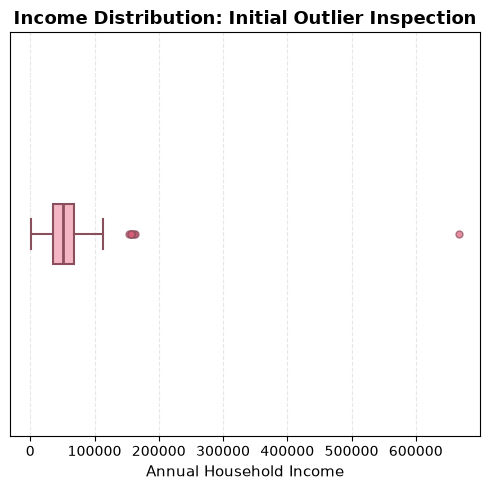

In [129]:
# Visualize the Income distribution to identify potential extreme values
plt.figure(figsize=(5, 5))

plt.boxplot(
    df["Income"],
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="#F4B6C2", edgecolor="#8A4F5D", linewidth=1.5),
    medianprops=dict(color="#8A4F5D", linewidth=2),
    whiskerprops=dict(color="#8A4F5D", linewidth=1.5),
    capprops=dict(color="#8A4F5D", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="#D95D78",
        markeredgecolor="#8A4F5D",
        markersize=5,
        alpha=0.7
    )
)

plt.title("Income Distribution: Initial Outlier Inspection", fontsize=13, fontweight="bold")
plt.xlabel("Annual Household Income", fontsize=11)
plt.yticks([])
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

The boxplot confirms the presence of potential high-end outliers in 'Income'. Most customers are concentrated within a substantially lower income range, while one observation appears extremely distant from the rest of the distribution. To quantify these potential outliers more systematically, the Interquartile Range method is applied next.

In [130]:
# Compute the IQR-based bounds for Income outlier detection
Q1_income = df["Income"].quantile(0.25)
Q3_income = df["Income"].quantile(0.75)
IQR_income = Q3_income - Q1_income

lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income

Q1_income, Q3_income, IQR_income, lower_bound_income, upper_bound_income

(np.float64(35246.0),
 np.float64(68487.0),
 np.float64(33241.0),
 np.float64(-14615.5),
 np.float64(118348.5))

Using the Interquartile Range method, the upper outlier threshold for 'Income' is set at 118,348.5. Since income cannot be negative, the lower bound is not analytically relevant in this case. Observations above the upper threshold are flagged for closer inspection before deciding whether they should be retained or removed.

In [131]:
# Count potential Income outliers above the IQR upper bound
(df["Income"] > upper_bound_income).sum()

np.int64(8)

The IQR screening identifies 8 customers with income values above the upper threshold. These observations are not removed automatically, since high income may reflect rare but valid customer profiles. The flagged records are inspected before defining the final treatment.

In [132]:
# Inspect customers flagged as potential high-income outliers
df[df["Income"] > upper_bound_income].sort_values("Income", ascending=False)[
    ["ID", "Year_Birth", "Education", "Marital_Status", "Income"]
]

,ID,Year_Birth,Education,Marital_Status,Income
2233,9432,1977,Graduation,Together,666666.0
617,1503,1976,PhD,Together,162397.0
687,1501,1982,PhD,Married,160803.0
1300,5336,1971,Master,Together,157733.0
164,8475,1973,PhD,Married,157243.0
1653,4931,1977,Graduation,Together,157146.0
2132,11181,1949,PhD,Married,156924.0
655,5555,1975,Graduation,Divorced,153924.0


The inspection shows that most IQR-flagged observations fall within a relatively compact high-income range, between approximately 153,000 and 162,000. These values are uncommon but still plausible and therefore retained.

Conversely, the record with an income of 666,666 is clearly isolated from the rest of the distribution and is more than four times higher than the next-largest value. This observation is treated as an extreme anomaly and removed to prevent it from disproportionately affecting the subsequent spending analysis and segmentation steps.

In [133]:
# Remove the single extreme Income anomaly
df = df[df["Income"] != 666666].copy()

In [134]:
# Verify that the extreme Income anomaly has been removed
df["Income"].max(), df.shape

(np.float64(162397.0), (2212, 27))

After removing the single extreme income anomaly, the maximum observed 'Income' value is 162,397. The remaining high-income records are retained as plausible rare customer profiles. The working dataset now contains 2,212 customers.

After resolving the isolated income anomaly, the remaining monetary and behavioral variables are screened visually for unusually high values. These variables are inspected in two separate groups, product spending and purchase behavior, because they capture different dimensions of customer activity and operate on different numerical scales.

In [135]:
# Select key monetary and purchase-behaviour variables for outlier screening
outlier_check_columns = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth"
]

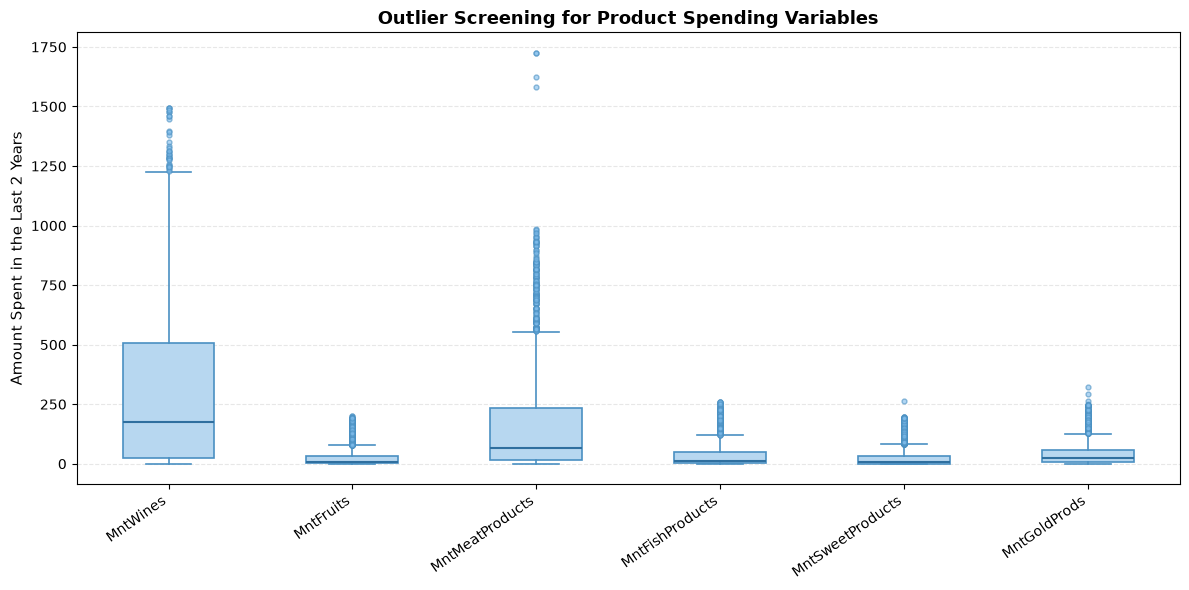

In [136]:
# Visualize potential outliers in product spending variables
spending_columns = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    [df[col] for col in spending_columns],
    tick_labels=spending_columns,
    patch_artist=True,
    boxprops=dict(facecolor="#B7D7F0", edgecolor="#4A90C2", linewidth=1.2),
    medianprops=dict(color="#2F6F9F", linewidth=1.5),
    whiskerprops=dict(color="#4A90C2", linewidth=1.2),
    capprops=dict(color="#4A90C2", linewidth=1.2),
    flierprops=dict(
        marker="o",
        markerfacecolor="#7FBCEB",
        markeredgecolor="#4A90C2",
        markersize=3.5,
        alpha=0.6
    )
)

plt.title("Outlier Screening for Product Spending Variables", fontsize=13, fontweight="bold")
plt.ylabel("Amount Spent in the Last 2 Years", fontsize=11)
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

The spending variables show several observations above the boxplot whiskers, especially for wine and meat products. However, these values represent cumulative customer spending over a two-year period and may reflect genuinely high-value customers rather than data errors. Since no isolated implausible value emerges as clearly as in the 'Income' variable, these observations are retained at this stage.

Purchase and website activity variables are then examined separately to assess whether unusually high interaction counts may reflect data anomalies or simply highly engaged customer behavior.

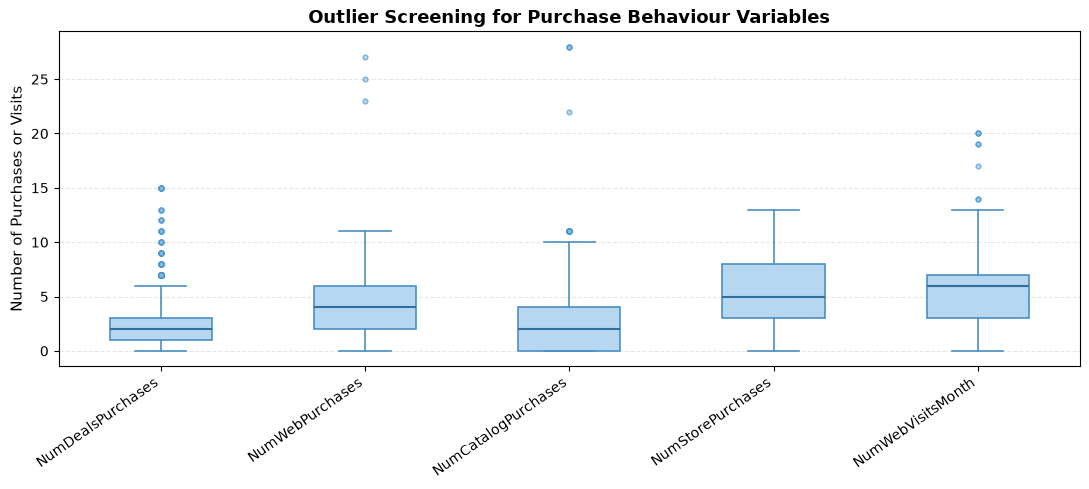

In [137]:
# Visualize potential outliers in purchase behaviour variables
purchase_columns = [
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

plt.figure(figsize=(11, 5))

plt.boxplot(
    [df[col] for col in purchase_columns],
    tick_labels=purchase_columns,
    patch_artist=True,
    boxprops=dict(facecolor="#B7D7F0", edgecolor="#4A90C2", linewidth=1.2),
    medianprops=dict(color="#2F6F9F", linewidth=1.5),
    whiskerprops=dict(color="#4A90C2", linewidth=1.2),
    capprops=dict(color="#4A90C2", linewidth=1.2),
    flierprops=dict(
        marker="o",
        markerfacecolor="#7FBCEB",
        markeredgecolor="#4A90C2",
        markersize=3.5,
        alpha=0.6
    )
)

plt.title("Outlier Screening for Purchase Behaviour Variables", fontsize=13, fontweight="bold")
plt.ylabel("Number of Purchases or Visits", fontsize=11)
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

The purchase behavior variables also show a limited number of high-end observations, especially for web and catalogue purchases. However, these values remain plausible within the customer activity context and do not present the same isolated extreme  pattern previously observed for 'Income'. They are therefore retained as potentially meaningful indicators of highly active or digitally engaged customers.

### **Final Clean Dataset**

After the data audit and cleaning process, the dataset is ready for the exploratory analysis and segmentation stages. The main interventions applied were the removal of records with missing Income, the correction of the Dt_Customer data type, the harmonization of non-standard marital status labels, the removal of three implausible birth-year records and the removal of one clearly isolated extreme income anomaly. The remaining high-end values in spending and purchase behavior are retained, as they appear plausible and may capture genuinely valuable or highly engaged customer profiles.

In [138]:
df.shape

(2212, 27)

In [139]:
df.isna().sum().sum()

np.int64(0)

The final analytical dataset contains 2,212 customer records and 27 variables, with no remaining missing values. This cleaned base will be used for the exploratory analysis, RFM segmentation and cluster analysis that follow.

## **Exploratory Data Analysis (EDA)**

With the cleaned analytical dataset in place, the analysis now moves from data quality assessment to the exploration of customer behavior and marketing-relevant patterns.

This section focuses on three objectives: understanding how socio-demographic characteristics related to overall customer spending, examining how purchases are distributed across different sales channels and identifying a less obvious behavioral trend that could support a targeted promotional campaign.

### **Analytical Feature Engineering for the EDA**

Before examining customer patterns, two variables are engineered to make the exploratory analysis more interpretable. 'Total_Spending' provides a single customer-level measure of overall monetary value across product categories, while 'Age' translates the original birth-year information into a more intuitive socio-demographic feature.

In [140]:
# Create the total amount spent by each customer across all product categories
spending_columns = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

df["Total_Spending"] = df[spending_columns].sum(axis=1)

In [141]:
# Verify the newly created Total_Spending variable
df[spending_columns + ["Total_Spending"]].head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending
0,635,88,546,172,88,88,1617
1,11,1,6,2,1,6,27
2,426,49,127,111,21,42,776
3,11,4,20,10,3,5,53
4,173,43,118,46,27,15,422


'Total_Spending' is created by summing the amount spent by each customer across all product categories. This variable provides a customer-level measure of overall monetary value and will be used to investigate how socio-demographic characteristics relate to spending behavior.

The second engineered variable converts birth year into approximate customer age, which is easier to interpret when discussing socio-demographic differences in spending.

In [142]:
# Create Age variable using the latest customer enrollment year as reference
reference_year = df["Dt_Customer"].dt.year.max()

df["Age"] = reference_year - df["Year_Birth"]

reference_year

np.int32(2014)

In [143]:
# Verify the newly created Age variable
df[["Year_Birth", "Age"]].head()

,Year_Birth,Age
0,1957,57
1,1954,60
2,1965,49
3,1984,30
4,1981,33


Age is computed using the latest customer enrollment year available in the dataset as the reference year. This makes the feature construction more consistent with the observed data instead of relying on a manually fixed year.

### **Socio-Demographic Features and Total Spending**

The first objective of the EDA is to examine how selected socio-demographic characteristics relate to overall customer monetary value. 
Numerical variables such as 'Income' and 'Age' are evaluated through correlation analysis and scatter plot, while categorical or discrete household features are explored through group summaries and boxplots. This combination allows both linear associations and distributional differences across customer groups to be assessed.

'Income' is first examined because it is the most direct socio-economic indicator available in the dataset and may strongly influence the customer's ability to generate monetary value.

In [144]:
# Inspect the correlation between Income and Total Spending
df[["Income", "Total_Spending"]].corr()

,Income,Total_Spending
Income,1.00000,0.79274
Total_Spending,0.79274,1.00000


'Income' and 'Total_Spending' show a strong positive correlation of approximately 0.79, This suggests that customers with higher household income tend to generate higher overall spending across product categories. Since income is a key socio-demographic feature, this results provides an important first indication of how customer economic profile relates to monetary value.

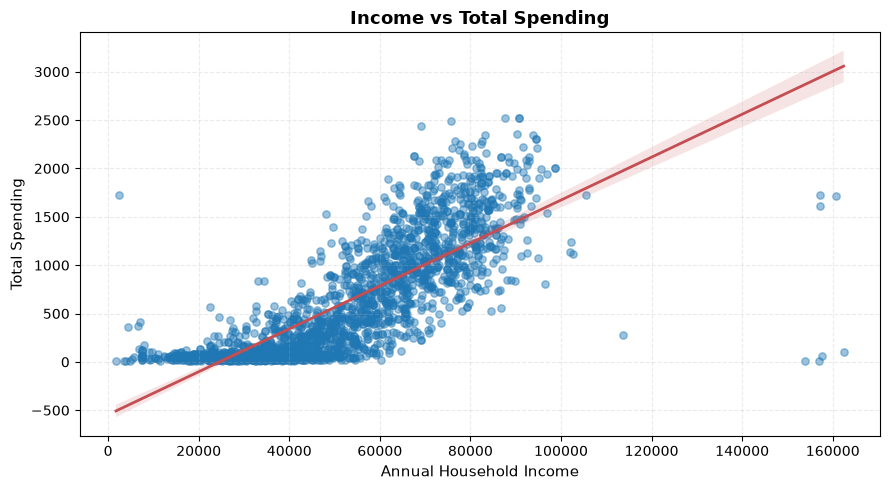

In [145]:
# Visualize the relationship between Income and Total Spending
plt.figure(figsize=(9, 5))

sns.regplot(
    data=df,
    x="Income",
    y="Total_Spending",
    scatter_kws={"alpha": 0.45, "s": 28},
    line_kws={"color": "#C44E52", "linewidth": 2}
)

plt.title("Income vs Total Spending", fontsize=13, fontweight="bold")
plt.xlabel("Annual Household Income", fontsize=11)
plt.ylabel("Total Spending", fontsize=11)
plt.grid(axis="both", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

The scatter plot confirms the strong positive relationship between 'Income' and 'Total_Spending': customers with higher household income generally tend to spend more across product categories.

At the same time, the relationship is not perfectly deterministic. A small number of high-income customers show relatively low total spending, suggesting that economic potential alone does not fully explain customer value. This reinforces the need to complement socio-demographic analysis with behavioral segmentation in the later stages of the project.

'Age' is then evaluated to understand whether customer life stage, approximated from birth year, is associated with higher or lower overall spending.

In [146]:
# Inspect the correlation between Age and Total Spending
df[["Age", "Total_Spending"]].corr()

,Age,Total_Spending
Age,1.000000,0.115901
Total_Spending,0.115901,1.000000


'Age' shows only a very weak positive correlation with 'Total_Spending', approximately 0.12. Unlike income, customer age does not appear to be a strong standalone indicator of overall monetary value in this dataset.

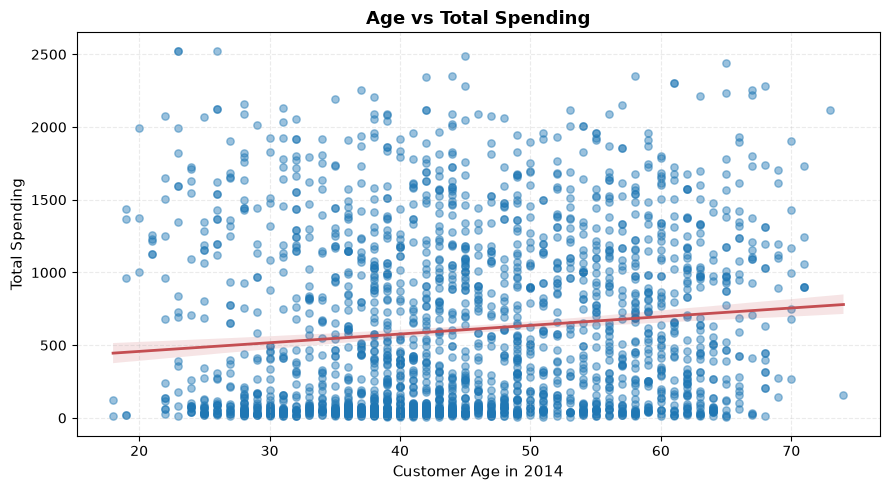

In [147]:
# Visualize the relationship between Age and Total Spending
plt.figure(figsize=(9, 5))

sns.regplot(
    data=df,
    x="Age",
    y="Total_Spending",
    scatter_kws={"alpha": 0.45, "s": 28},
    line_kws={"color": "#C44E52", "linewidth": 2}
)

plt.title("Age vs Total Spending", fontsize=13, fontweight="bold")
plt.xlabel("Customer Age in 2014", fontsize=11)
plt.ylabel("Total Spending", fontsize=11)
plt.grid(axis="both", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

The scatter plot confirms that the relationship between 'Age' and 'Total_Spending' is weak. Customers with both low and high spending levels are distributed across most groups, indicating that age alone is not sufficient to identify high-value customers. Compared with income, age appears to have a much more limited role in explaining overall spending behavior.

### **Education and Total Spending**  
Unlike 'Income' and 'Age', 'Education' is categorical and is therefore examined by comparing spending summaries across education levels. The table provides a compact numerical view, while the boxplot is used to assess the full distribution and the degree of overlap between groups.


In [148]:
# Summarize Total Spending across education levels
education_spending = (
    df.groupby("Education")["Total_Spending"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
    .round(2)
)

education_spending

,count,mean,median
Education,,,
PhD,480,674.28,494.0
Graduation,1115,622.19,415.0
Master,365,609.77,385.0
2n Cycle,198,499.49,207.5
Basic,54,81.80,57.0


The summary suggests that overall spending tends to be higher among customers with more advanced education levels. 'PhD', 'Graduation' and 'Master' customers show substantially higher median spending than '2n Cycle' and especially 'Basic' customers.

The median is particularly useful here because total spending is affected by high-value customers, making it a more robust measure of the typical spending behavior within each education group.

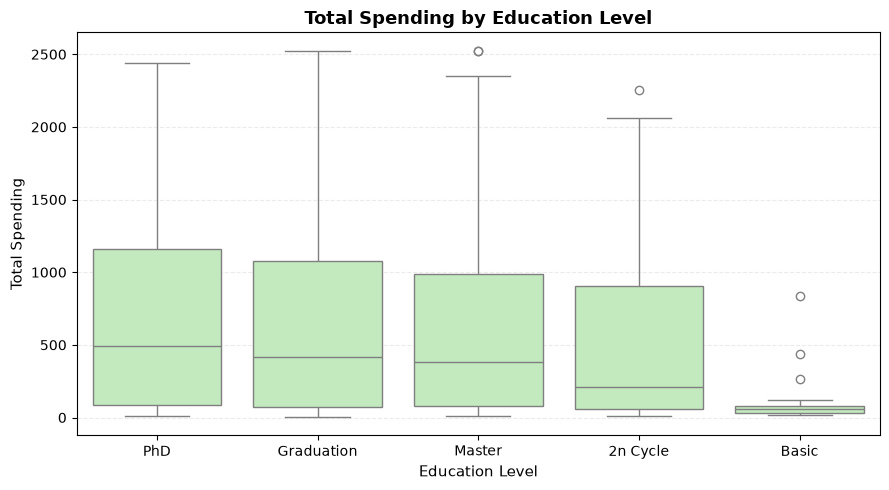

In [149]:
# Visualize Total Spending across education levels
education_order = education_spending.index.tolist()

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Education",
    y="Total_Spending",
    order=education_order,
    color="#BDF0B7"
)

plt.title("Total Spending by Education Level", fontsize=13, fontweight="bold")
plt.xlabel("Education Level", fontsize=11)
plt.ylabel("Total Spending", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

The boxplot confirms that spending tends to be higher among customers with more advanced education levels, particularly when comparing 'PhD', 'Graduation' and 'Master' customers with the 'Basic' group. At the same time, the wide overlap between the upper education categories suggests that education is informative, but not sufficient on its own to define distinct high-value customer profiles.

### **Marital Status and Total Spending**  
'Marital_Status' is explored to assess whether relationship status is associated with meaningful differences in customer monetary value. As for education, a numerical summary is used first and then complemented with a boxplot to evaluate the degree of separation or overlap across categories.

In [150]:
# Summarize Total Spending across marital status groups
marital_spending = (
    df.groupby("Marital_Status")["Total_Spending"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
    .round(2)
)

marital_spending

,count,mean,median
Marital_Status,,,
Other/Unknown,4,808.25,796.5
Widow,76,727.96,625.5
Divorced,231,612.99,400.0
Married,857,591.46,396.0
Together,571,607.63,395.0
Single,473,611.58,369.0


The summary indicates some differences in total spending across marital status groups. However, the 'Other/Unknown' category contains only four customers and is therefore not interpreted as a meaningful behavioral segment.

Among the clearly interpretable categories, 'Widow' customers show the highest median total spending, while 'Single', 'Married', 'Together' and 'Divorced' customers display more comparable spending levels. Overall, marital status appears to provide some descriptive variation, but the differences are less pronounced than those observed for income or education.

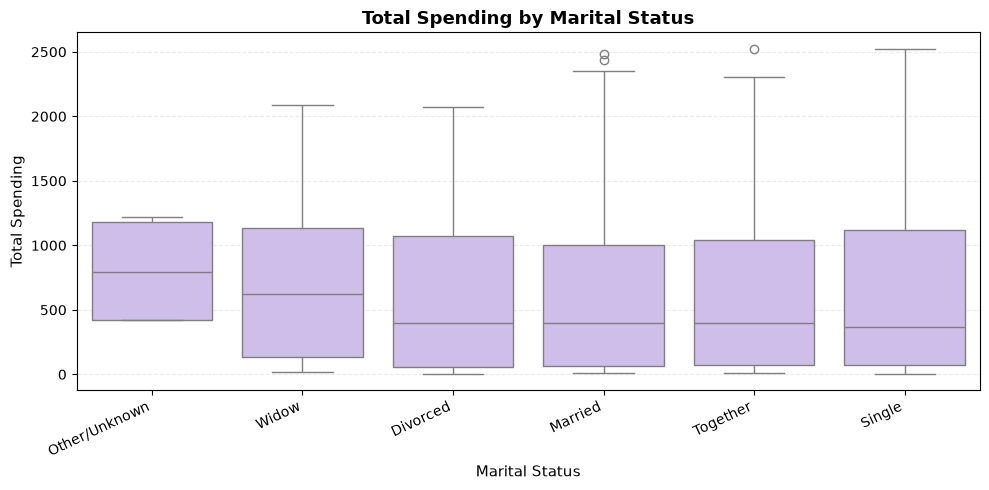

In [151]:
# Visualize Total Spending across marital status groups
marital_order = marital_spending.index.tolist()

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Marital_Status",
    y="Total_Spending",
    order=marital_order,
    color="#CCB7F0"
)

plt.title("Total Spending by Marital Status", fontsize=13, fontweight="bold")
plt.xlabel("Marital Status", fontsize=11)
plt.ylabel("Total Spending", fontsize=11)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

The boxplot confirms that marital status provides only moderate descriptive differences in total spending. 'Widow' customers show a higher median spending level, but the distributions of 'Divorced', 'Married', 'Together' and 'Single' customers substantially overlap.

The 'Other/Unknown' category is retained for transparency, but is not interpreted as a meaningful customer segment because it contains only four observations.

### **Household Composition and Total Spending**  
To obtain a more compact representation of dependent children in the household, 'Kidhome' and 'Teenhome' are combined into a single variable, 'Total_Children'. This engineered feature makes it easier to assess whether overall household child composition is associated with differences in customer spending.

In [152]:
# Create a household composition variable combining children and teenagers at home
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [153]:
# Inspect the distribution of the Total_Children variable
df["Total_Children"].value_counts().sort_index()

Total_Children
0     632
1    1114
2     416
3      50
Name: count, dtype: int64

'Total_Children' combines the number of children and teenagers living in the household. Most customers have one child or teenager at home, while household with three are relatively rare but still present in the dataset.

In [154]:
# Summarize Total Spending across household child composition
children_spending = (
    df.groupby("Total_Children")["Total_Spending"]
    .agg(["count", "mean", "median"])
    .sort_index()
    .round(2)
)

children_spending

,count,mean,median
Total_Children,,,
0,632,1104.06,1188.5
1,1114,475.84,307.5
2,416,246.74,93.5
3,50,255.50,79.5


Household composition shows a clear relationship with customer spending. Customers with no children or teenagers at home report substantially higher total spending, with a median value of 1,188.5 compared with 307.5 for household with one child and below 100 for households with two or three.

This suggests that customers without dependent children may allocate a larger share of their budget to the product categories represented in the dataset, making household composition a relevant socio-demographic factor for customer value analysis.

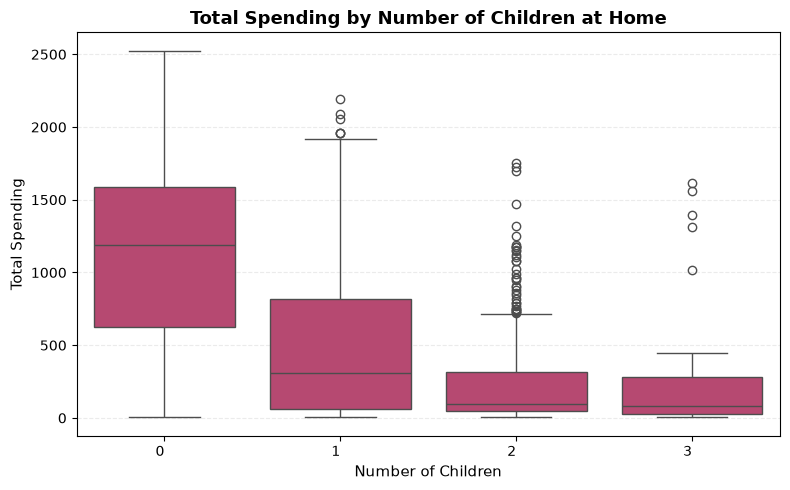

In [155]:
# Visualize Total Spending across household child composition groups
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Total_Children",
    y="Total_Spending",
    color="#C8376C"
)

plt.title("Total Spending by Number of Children at Home", fontsize=13, fontweight="bold")
plt.xlabel("Number of Children", fontsize=11)
plt.ylabel("Total Spending", fontsize=11)
plt.xticks(rotation=0, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

The boxplot confirms a strong decline in total spending as the number of children or teenagers in the household increases. Customers with no children at home show a clearly higher median spending level and a wider concentration of high-value observations.

Household with one, two or three children are instead associated with substantially lower typical spending. This suggests that household composition is one of the most informative socio-demographic factors for distinguishing customer monetary value in this dataset.

### **Synthesis of Numerical Socio-Demographic Relationships**  
After inspecting each socio-demographic factor separately, a compact correlation overview is used to summarize the numerical relationship involving 'Income', 'Age', 'Total_Children' and 'Total_Spending'. This provides a final comparative view of the strongest and weakest associations observed in the previous analyses.

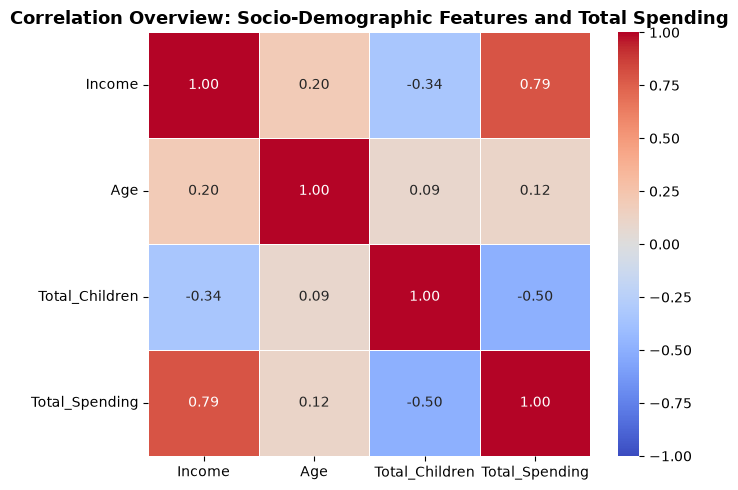

In [156]:
# Correlation overview between numerical socio-demographic features and Total Spending
socio_demo_corr = df[
    ["Income", "Age", "Total_Children", "Total_Spending"]
].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    socio_demo_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Correlation Overview: Socio-Demographic Features and Total Spending",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Overall, the socio-demographic analysis shows that 'Income' is the strongest factor associated with 'Total_Spending', with a clear positive relationship of 0.79 between household income and customer monetary value. 'Education' also reveals meaningful differences, as customers with higher education levels tend to spend more on average and at the median level.

By contrast, 'Age' shows only a weak relationship with total spending, while 'Marital_Status' provides more limited descriptive differences across groups. A particularly relevant pattern emerges from household composition: customers with no children or teenagers at home display substantially higher spending levels than households with dependent children. This variable therefore appears especially informative for understanding differences in customer value.

##  **Purchase Distribution Across Channels**

After examining how socio-demographic characteristics relate to customer spending, the analysis turns to purchase behavior across sales channels. The dataset records purchases completed through three main channels: web, catalogue and physical stores.

Understanding how customers distribute their purchases across these channels is relevant for communication strategy, since different channel preferences may suggest different contact points, campaign formats and promotional opportunities.

In [157]:
# Summarize purchases across the three main sales channels
channel_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

channel_summary = pd.DataFrame({
    "Total Purchases": df[channel_columns].sum(),
    "Average per Customer": df[channel_columns].mean().round(2),
    "Median per Customer": df[channel_columns].median()
}).sort_values("Total Purchases", ascending=False)

channel_summary

,Total Purchases,Average per Customer,Median per Customer
NumStorePurchases,12844,5.81,5.0
NumWebPurchases,9043,4.09,4.0
NumCatalogPurchases,5911,2.67,2.0


The channel summary shows that physical stores generate the highest overall purchase volume, with 12,844 purchases and a median of 5 purchases per customer. Web purchases represent the second most used channel, while catalogue purchases are clearly less frequent.

This suggests that the customer base remains strongly connected to the offline retail channel, although digital purchasing already plays a relevant complementary role.

The aggregate channel hierarchy is visualized directly to make the differences in total purchase volume easier to compare at a glance.

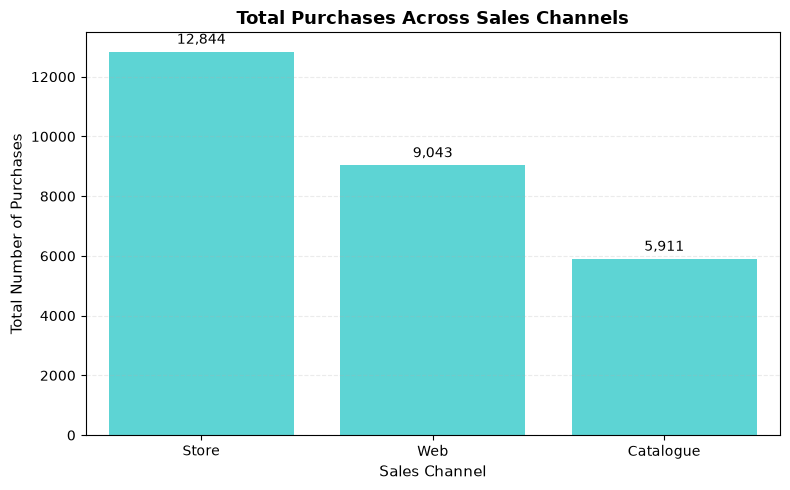

In [158]:
# Visualize the total number of purchases generated by each sales channel
channel_totals = channel_summary["Total Purchases"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=channel_totals.index,
    y=channel_totals.values,
    color="#49E8E8"
)

plt.title("Total Purchases Across Sales Channels", fontsize=13, fontweight="bold")
plt.xlabel("Sales Channel", fontsize=11)
plt.ylabel("Total Number of Purchases", fontsize=11)
plt.xticks(
    ticks=range(len(channel_totals.index)),
    labels=["Store", "Web", "Catalogue"]
)
plt.grid(axis="y", linestyle="--", alpha=0.25)

# Add value labels above the bars
for i, value in enumerate(channel_totals.values):
    ax.text(i, value + 150, f"{value:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

The bar chart makes the channel hierarchy immediately visible. Store purchases represent the largest share of observed buying activity, with 12,844 purchases, followed by web purchases with 9,043. Catalogue purchases remain clearly lower, with 5,911 transactions. 

This pattern suggests that physical retail is still the primary transaction channel for this customer base, but the web channel is already sufficiently relevant to support dedicated digital communication and conversion strategies.

Total purchases by channel indicate aggregate volume, but they do not show how purchase activity is distributed across individual customers. A boxplot is therefore used to compare typical customer-level behavior and identify whether some channels are more concentrated among specific high-activity profiles.

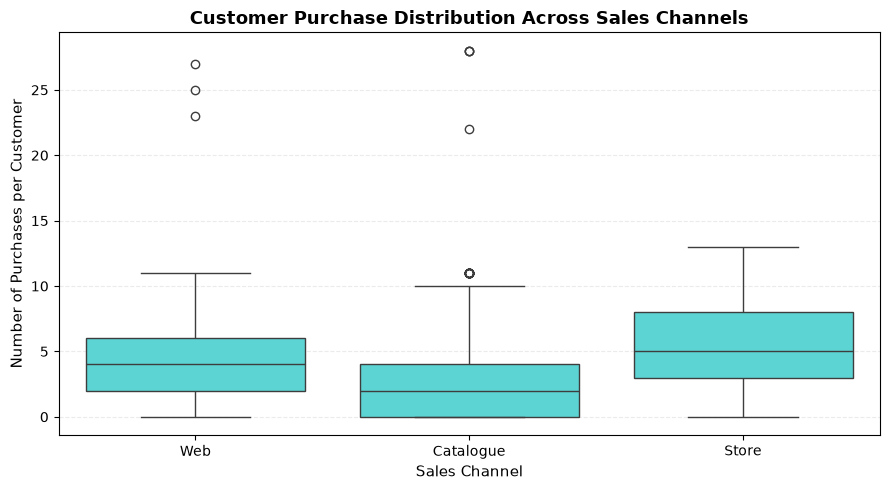

In [159]:
# Visualize customer-level purchase distributions across sales channels
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df[channel_columns],
    color="#49E8E8"
)

plt.title("Customer Purchase Distribution Across Sales Channels", fontsize=13, fontweight="bold")
plt.xlabel("Sales Channel", fontsize=11)
plt.ylabel("Number of Purchases per Customer", fontsize=11)
plt.xticks(
    ticks=range(len(channel_columns)),
    labels=["Web", "Catalogue", "Store"]
)
plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

The customer-level distribution confirms that store purchases are the most common channel behavior, with the highest median number of purchases per customer. Web purchases follow closely, showing that digital buying is already well established within the customer base.

Catalogue purchases are less frequent for the typical customer, but the presence of a few high-end observations suggests that this channel may still be particularly relevant for a smaller niche of highly engaged customers. Overall, the three channels do not play the same role: stores dominate broadly, web is a strong complementary channel and catalogue appears more selective.

## **Communication Insight: Customers Spending Below Their Income Potential**

The previous analysis showed a strong positive relationship between 'Income' and 'Total_Spending': in general, customers with higher household income tend to generate higher monetary value. However, the scatter plot also suggested that not all customers follow this pattern equally closely.

Some customers appear to spend substantially less than what would be expected given their income level. This is a potentially valuable communication insight, because it may reveal an under-activated audience with strong economic potential that has not yet translated into comparable customer value. The following analysis identifies these customers by comparing their observed spending with the spending level predicted from their income.

In [160]:
# Fit a linear regression model to estimate expected spending from Income
income_model = LinearRegression()

X_income = df[["Income"]]
y_spending = df["Total_Spending"]

income_model.fit(X_income, y_spending)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.02]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-545.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


A simple linear regression is fitted to estimate the level of 'Total_Spending' expected from each customer's 'Income'. The purpose is not to build a predictive model for deployment, but to create a reference spending benchmark against which individual customers can be compared.

In [161]:
# Calculate predicted spending and residuals for each customer
df["Predicted_Spending"] = income_model.predict(X_income)
df["Spending_Residual"] = df["Total_Spending"] - df["Predicted_Spending"]

df[["Income", "Total_Spending", "Predicted_Spending", "Spending_Residual"]].head()

,Income,Total_Spending,Predicted_Spending,Spending_Residual
0,58138.0,1617,744.368793,872.631207
1,46344.0,27,482.689524,-455.689524
2,71613.0,776,1043.345234,-267.345234
3,26646.0,53,45.640326,7.359674
4,58293.0,422,747.807854,-325.807854


The residual measures the gap between observed and expected spending. A positive residual indicates that a customer spends more than predicted from income, while a negative residual indicates that the customer spends less than expected. 

Customers with strongly negative residuals are especially relevant for this analysis, since they may represent high-potential profiles whose current spending remains underdeveloped relative to their economic capacity.

The distribution of residuals is inspected to define a data-driven threshold for identifying customers whose spending falls substantially below their income-based expectation.

In [162]:
# Inspect the distribution of spending residuals
df["Spending_Residual"].describe()

count    2.212000e+03
mean     7.606533e-14
std      3.672682e+02
min     -2.950614e+03
25%     -2.251876e+02
50%     -3.716258e+01
75%      2.065386e+02
max      2.221275e+03
Name: Spending_Residual, dtype: float64

The residuals are centered around zero, as expected from a linear regression model, with a standard deviation of approximately 367. This spread can be used to define customers whose spending is meaningfully below the income-based expectation.

In the next step, customers with residual lower than one standard deviation below the mean are flagged as spending substantially less than predicted by their income level.

In [163]:
# Define the threshold for customers spending substantially below their income potential
residual_threshold = -df["Spending_Residual"].std()

residual_threshold

np.float64(-367.2681764126493)

The threshold is set at one standard deviation below the mean residual, equal to approximately -367.27. Customers below this value are spending markedly less than expected given their income level and are therefore flagged as a potential under-activated segment.

In [164]:
# Identify customers spending substantially below their income-based expectation
below_income_potential = df[
    df["Spending_Residual"] < residual_threshold
].copy()



# Calculate the share of customers spending below their income potential
below_income_potential_share = (
    len(below_income_potential) / len(df) * 100
)

below_income_potential.shape, below_income_potential_share

((260, 32), 11.754068716094032)

The residual-based approach identifies 260 customers whose spending is more than one standard deviation below the income-based expectation. This group represents approximately 11.8% of the customer base.

Rather than being low-income or structurally low-value customers, these profiles appear to have relevant economic potential that is not yet reflected in their purchasing behavior. They therefore represent a meaningful target for a dedicated activation campaign.

The segment is then quantified in business terms by comparing its observed spending with the spending level predicted by the income-based model. This makes the size of the unrealized value gap directly interpretable.

In [165]:
# Quantify the average spending gap for customers below their income potential
potential_summary = pd.Series({
    "Customers Identified": len(below_income_potential),
    "Share of Customer Base (%)": below_income_potential_share,
    "Average Income": below_income_potential["Income"].mean(),
    "Average Total Spending": below_income_potential["Total_Spending"].mean(),
    "Average Predicted Spending": below_income_potential["Predicted_Spending"].mean(),
    "Average Spending Gap": (
        below_income_potential["Predicted_Spending"] 
        - below_income_potential["Total_Spending"]
    ).mean()
}).round(2)

potential_summary

Customers Identified            260.00
Share of Customer Base (%)       11.75
Average Income                62131.77
Average Total Spending          281.60
Average Predicted Spending      832.98
Average Spending Gap            551.38
dtype: float64

The identified group represents 260 customers, equal to 11.75% of the customer base. Their average income is 62,131.77, yet their average observed spending is only 281.60, compared with an average income-based predicted spending of 832.98.

This corresponds to an average unrealized spending gap of approximately 551.38 per customer. The result strengthens the interpretation of this segment as an under-activated audience: these customers have a spending profile that is substantially below what their income level would suggest, making them a relevant target for value-development communication.

A dedicated visualization is used to make the hidden trend directly visible. Customers below the residual threshold are highlighted against the overall income-spending relationship, together with both the expected spending line and the underperformance boundary.

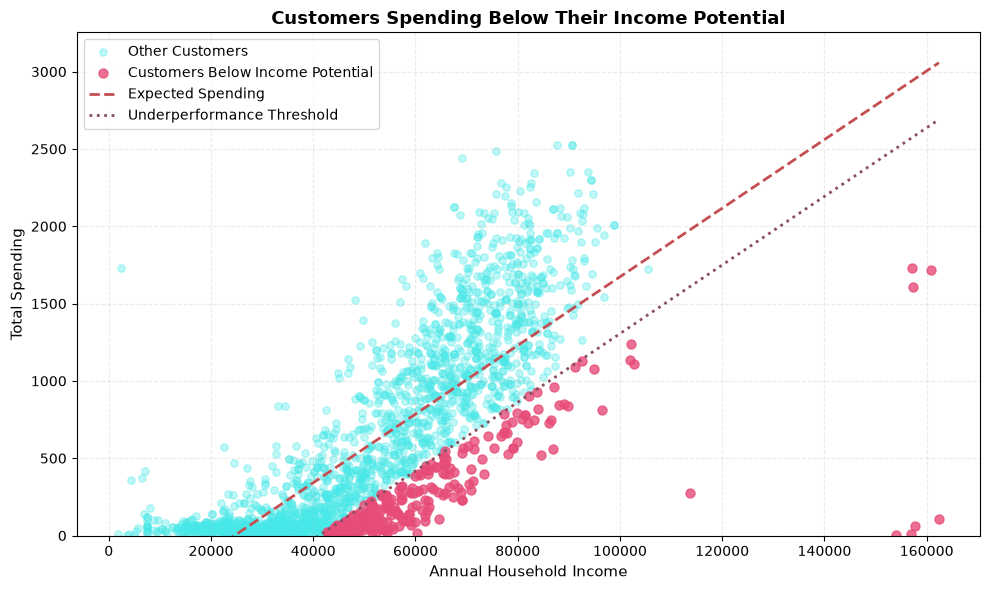

In [166]:
# Visualize customers spending substantially below their income potential
plt.figure(figsize=(10, 6))

# Separate regular customers from customers below their income potential
regular_customers = df[
    df["Spending_Residual"] >= residual_threshold
]

# Plot all other customers
plt.scatter(
    regular_customers["Income"],
    regular_customers["Total_Spending"],
    alpha=0.35,
    s=28,
    color="#49E8E8",
    label="Other Customers"
)

# Highlight customers below their income potential
plt.scatter(
    below_income_potential["Income"],
    below_income_potential["Total_Spending"],
    alpha=0.80,
    s=42,
    color="#E74C78",
    label="Customers Below Income Potential"
)

# Create a smooth income range
income_range = pd.DataFrame({
    "Income": np.linspace(
        df["Income"].min(),
        df["Income"].max(),
        300
    )
})

# Expected spending predicted by the regression model
predicted_line = income_model.predict(income_range)

# Boundary corresponding to one residual standard deviation below expectation
threshold_line = predicted_line + residual_threshold

# Plot expected spending line
plt.plot(
    income_range["Income"],
    predicted_line,
    color="#C44E52",
    linewidth=2,
    linestyle="--",
    label="Expected Spending"
)

# Plot underperformance threshold line
plt.plot(
    income_range["Income"],
    threshold_line,
    color="#8A4F5D",
    linewidth=2,
    linestyle=":",
    label="Underperformance Threshold"
)

plt.title(
    "Customers Spending Below Their Income Potential",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Annual Household Income", fontsize=11)
plt.ylabel("Total Spending", fontsize=11)

plt.grid(axis="both", linestyle="--", alpha=0.25)
plt.ylim(bottom=0)
plt.legend()

plt.tight_layout()
plt.show()

The visualization makes the hidden trend explicit. Customers highlighted in pink fall below the underpeformance threshold, meaning that their observed spending is more than one residual standard deviation lower than the level expected from their income.

These customers are not simply low spenders in absolute terms: they are customers whose monetary value is unusually low relative to their economic potential. This makes them a particular interesting audience for a targeted activation strategy aimed at developing unrealized customer value.

Finally, the identified group is compared with the rest of the customer base to understand whether the underperformance pattern is associated with additional behavioral or household characteristics.

In [167]:
# Compare customers below their income potential with the rest of the customer base
comparison_columns = [
    "Income",
    "Total_Spending",
    "Predicted_Spending",
    "NumWebVisitsMonth",
    "NumWebPurchases",
    "Recency",
    "Total_Children"
]

other_customers = df[
    df["Spending_Residual"] >= residual_threshold
]

income_potential_comparison = pd.DataFrame({
    "Below Income Potential": below_income_potential[comparison_columns].mean(),
    "Other Customers": other_customers[comparison_columns].mean()
}).round(2)

income_potential_comparison

,Below Income Potential,Other Customers
Income,62131.77,50603.81
Total_Spending,281.60,650.65
Predicted_Spending,832.98,577.20
NumWebVisitsMonth,4.41,5.44
NumWebPurchases,3.13,4.22
Recency,48.50,49.09
Total_Children,1.33,0.90


 The comparison table confirms that customers below their income potential are economically stronger than the rest of the customer base, with a higher average income, but they generate much lower observed spending than expected. Their average spending is 281.60, compared with 650.65 for other customers, despite a higher income-based predicted value.

The segment also shows lower web activity and fewer web purchases, while 'Recency' remains almost identical to the rest of the database. This suggests that the gap is not mainly driven by longer purchase inactivity, but rather by weaker value development and lower digital purchasing engagement. 

A further distinctive element is household composition: these customers report a higher average number of children or teenagers at home. This is noteworthy because, despite their stronger income profile and potentially larger household needs, they spend less than expected within the product categories represented in the dataset. Their lower value may therefore reflect a combination of under-activation and a consumption profile that is not yet fully aligned with the retailer's current offer.

From a communication perspective, this segment represents a clear activation opportunity. These customers have stronger economic potential than the average customer, yet their purchasing value remains substantially below expectations and their digital activity is also weaker.

A targeted promotional campaign could therefore focus on personalized value-development messages, such as premium product discovery, exclusive bundles or tailored recommendations designed to stimulate additional spending. Since the group is not characterized by higher recency, the objective is not primarily win-back, but rather the activation of unrealized spending potential among customers who are already present in the database but are not contributing at the level suggested by their profile.

# **RFM Calculation and Heuristic Segmentation**

After the exploratory analysis, the project moves from describing customer behavior to classifying customers into actionable groups. 
The objective of this section is to build an RFM segmentation, a deterministic approach that summarizes each customer through three behavioural dimensions: Recency, Frequency and Monetary value.

**Recency** measures how recently a customer purchased. Lower values indicate more recent activity and therefore stronger current engagement.
**Frequency** measures how often the customer purchased during the observation period, capturing repeat buying behavior.
**Monetary** measures the total amount spent and represents the economic value generated by the customer.

In this project, customers are scored on each RFM dimension using quantiles. The resulting scores are then combined to define heuristic customer segments that can support marketing decisions and targeted communication strategies.

### **Engineering the RFM features**
The first step is to construct the three variables required for RFM segmentation. In this dataset. **Recency** is already available.
**Frequency** is engineered by summing the number of purchases made through the three main sales channels: web, catalogue and store. However, the variable NumDealsPurchases is not included in the calculation as it refers to purchases made with discounts rather than to a separate purchasing channel, so including it could double-count customer activity.
**Monetary** is represented by the variable Total_Spending, previously created by summing the amount spent across all product categories.
The resulting RFM dataset contains one row per customer and provides the behavioral foundation for the heuristic segmentation.

In [168]:
# RFM dataset
rfm = df[["ID", "Recency", "Total_Spending", "NumWebPurchases"]].copy()

# Frequency
rfm["Frequency"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

# Total_Spending renamed as Monetary
rfm.rename(columns={"Total_Spending": "Monetary"}, inplace=True)

rfm = rfm[["ID", "Recency", "Frequency", "Monetary"]]

rfm.head()


,ID,Recency,Frequency,Monetary
0,5524,58,22,1617
1,2174,38,4,27
2,4141,26,20,776
3,6182,26,6,53
4,5324,94,14,422


The RFM dataset contains one row per customer and the three dimensions required for segmentation, such as Monetary, Frequency and Recency.

In [169]:
# Check potential inconsistency between zero Frequency and positive Monetary value
rfm[(rfm["Frequency"] == 0) & (rfm["Monetary"] > 0)]

,ID,Recency,Frequency,Monetary
655,5555,81,0,6
981,3955,20,0,6
1245,6862,65,0,8
1524,11110,56,0,5
1846,9931,29,0,9
2132,11181,85,0,8


In [170]:
# Check potential inconsistency between positive Frequency and zero Monetary value
rfm[(rfm["Frequency"] > 0) & (rfm["Monetary"] == 0)]

,ID,Recency,Frequency,Monetary


In [171]:
# Remove customers with positive Monetary value but no recorded purchase frequency from the RFM dataset
rfm = rfm[~((rfm["Frequency"] == 0) & (rfm["Monetary"] > 0))].copy()

# Verify the updated RFM dataset size
rfm.shape

(2206, 4)

The consistency check identifies 6 customer records with positive monetary value but no recorded purchase frequency across the web, catalogue or store channels. Since the RFM framework requires a coherent relationship between purchase frequency and spending, these records are removed from the RFM dataset only. The original cleaned dataset is left unchanged for the previous exploratory analyses, while the RFM segmentation is based on 2,206 customers with logically consistent Recency, Frequency and Monetary values.

### **Verification of the RFM Variables**
Before assigning scores, the engineered RFM variables are inspected to verify their scale, range and distribution. This step is important because the three dimensions measure different aspects of customer behavior. Recency is measured in days, Frequency counts purchases and Monetary refers to the spending value.  
Checking them before scoring helps ensure that the quintile segmentation is based on coherent and interpretable variables.

In [172]:
# Inspection of distribution and scale of RFM variables
rfm[["Recency", "Frequency", "Monetary"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,2206.0,49.000453,28.952216,0.0,24.0,49.0,74.00,99.0
Frequency,2206.0,12.601088,7.185301,1.0,6.0,12.0,19.00,32.0
Monetary,2206.0,608.900725,602.517245,8.0,69.0,399.0,1048.75,2525.0


The summary confirms that the three RFM variables capture different dimensions of customer behavior and operate on different numerical scales.   
Recency ranges from 0 to 99 days, with a median of 49, which indicates that customers are spread across the full range of recent and less recent activity.  
Frequency ranges from 1 to 32 purchases, with a median of 12, indicating variation in repeat purchasing behaviour across customers.  
Monetary is more dispersed, ranging from 8 to 2525, with a median of 399 and a mean of approximately 607, suggesting the presence of high-value customers who spend substantially more than the typical customer.

Since these variables have all different scales and distributions, they should not be combined directly in their raw form. Instead, each dimension will be converted into a quintile-based score, so that customers can be compared consistently across Recency, Frequency and Monetary value.

### **Visual Inspection of RFM Distributions**
Before assigning quintile scores, the three RFM variables are visually inspected. These steps helps verify whether the variables show concentration, skewness or high-end values that may affect the interpretation of the score classes. The goal is to not remove observations at this stage, because high Frequency or Monetary values may represent genuinely valuable customers, but to understand their structure before transforming them into scores.

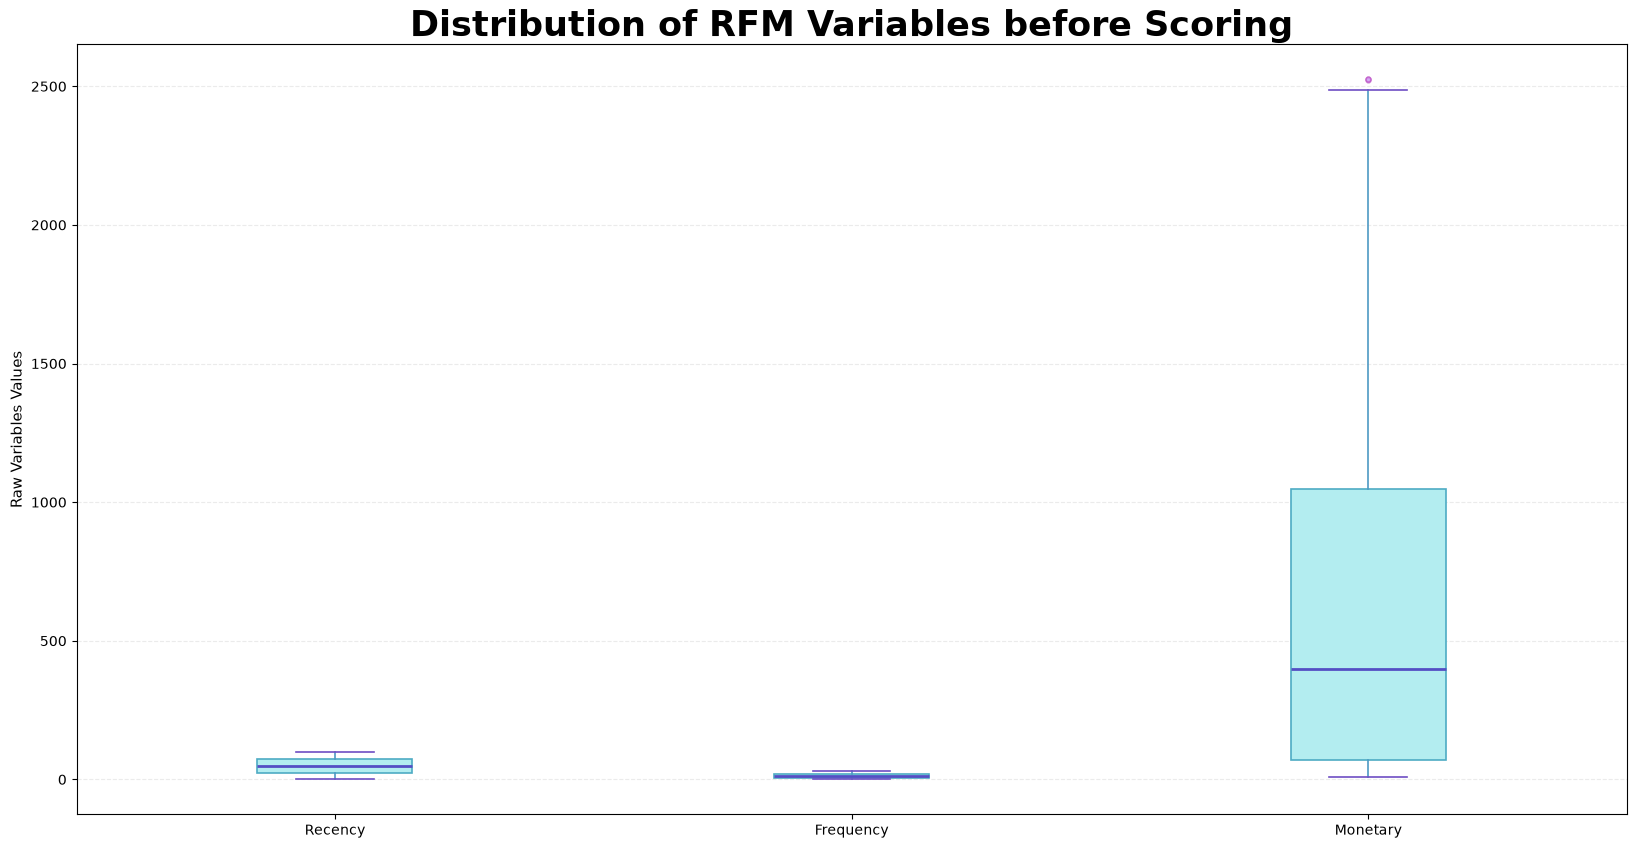

In [173]:
# Visualize the distribution of RFM variables
rfm_variables = ["Recency", "Frequency", "Monetary"]

plt.figure(figsize=(20, 10))

plt.boxplot(
    [rfm[var] for var in rfm_variables],
    tick_labels=rfm_variables,
    patch_artist=True,
    boxprops=dict(facecolor="#B3EDF0", edgecolor="#4EABC4", linewidth=1.2),
    medianprops=dict(color="#544EC4", linewidth=2),
    whiskerprops=dict(color="#4E99C4", linewidth=1.2),
    capprops=dict(color="#6E4EC4", linewidth=1.2),
    flierprops=dict(
        marker="o",
        markerfacecolor="#D3A6F4",
        markeredgecolor="#BC4EC4",
        markersize=3.5,
        alpha=0.6
    )
)

plt.title("Distribution of RFM Variables before Scoring", fontsize=25, fontweight="bold")
plt.ylabel("Raw Variables Values", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.show()

The visual inspection also confirms that the three RFM variables operate on different scales. Recency and Frequency have relatively compact ranges, while Monetary is much more dispersed and shows high-end values associated with customers who spend substantially more than average.  
These observations are not treated as anomalies at this stage, because high monetary value and high purchase activity are meaningful signals in customer segmentation.

Therefore, the next step is to convert the three RFM variables into a quintile-based score. This will allow customers to be compared across Monetary, Frequency and Recency value. 

### **Quintile-Based RFM Scoring**

Each RFM variable is transformed into a score from 1 to 5 using quintiles. This makes the three dimensions comparable even though they are measured on different scales.  
The scoring direction depends on the meaning of each variable. For Frequency and Monetary, higher values are better because they indicate more repeated purchasing activity and higher customer value. While for Recency, lower values are preferable as they indicate more recent purchases, thus the scoring is reverse and the highest score is assigned to most recent customers.

In [174]:
# Assigning quintile-based RFM scores

# Recency score: lower recency is better because it indicates more recent activity
rfm["Recency_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency score: higher frequency is better because it indicates stronger repeat purchase behavior
rfm["Frequency_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary score: higher monetary value is better because it indicates higher customer value
rfm["Monetary_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Verify the newly created RFM scores
rfm[[
    "ID", 
    "Recency", "Recency_Score", 
    "Frequency", "Frequency_Score", 
    "Monetary", "Monetary_Score"
]].head()

,ID,Recency,Recency_Score,Frequency,Frequency_Score,Monetary,Monetary_Score
0,5524,58,3,22,5,1617,5
1,2174,38,4,4,1,27,1
2,4141,26,4,20,4,776,4
3,6182,26,4,6,2,53,1
4,5324,94,1,14,3,422,3


The first rows of this table confirms that the scoring direction is coherent with the meaning of each variable. In fact, customers with more recent activity are assigned higher Recency_score, while customers with higher purchase frequency and higher spending receive higher Frequency and Monetary scores. 

Since each customer is represented by standardized behavioural scores, the transformation makes the three dimensions easier to combine.

### **RFM Code**

After assigning the three individual scores, the RFM is then created by combining them into a single three-digital label. The code provides a compact representation of each customer's behavioural profile.

In [175]:
# Combine the three RFM scores into a single three-digit RFM code
rfm["RFM_Code"] = (
    rfm["Recency_Score"].astype(str) +
    rfm["Frequency_Score"].astype(str) +
    rfm["Monetary_Score"].astype(str)
)

# Verify the resulting RFM code
rfm[
    [
        "ID",
        "Recency",
        "Frequency",
        "Monetary",
        "Recency_Score",
        "Frequency_Score",
        "Monetary_Score",
        "RFM_Code"
    ]
].head()

,ID,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Code
0,5524,58,22,1617,3,5,5,355
1,2174,38,4,27,4,1,1,411
2,4141,26,20,776,4,4,4,444
3,6182,26,6,53,4,2,1,421
4,5324,94,14,422,1,3,3,133


As shown, the three scores are combined into the "RFM score". The first digit represents Recency_Score, the second one refers to Frequency_Score and the last one to Monetary_Score.
For instance, the first code shown is "355", which identifies a customer with medium recency, but high frequency and monetary values.

### **Heuristic Segment Definition**
The quintile scores are then translated into customer segments. This step is heuristic because the segments are defined through explicit business rules based on the RFM scores, rather than through an automatic learning algorithm.

The segment names are chosen to reflect communication priorities.
* **Premium Core** identifies the stronger customer base, with recent activity and high frequency and monetary values
* **Repeat Buyers** refers to customers who purchase frequently and remain relatively engaged, even if they are not always the highest spenders
* **New Value Prospects** identifies recent customers whose value is still underdeveloped and may be increased through personalized offers or targeted marketing campaigns.
* **Reactivation Targets** represents customers with historical value or frequency, but weaker recent activity.
* **Low Engagement Base** collects the remaining customers, representing profiles with lower immediate priority for value-oriented campaigns. 


In [176]:
# Define heuristic customer segments based on RFM scores
def assign_rfm_segment(row):
    if (
        row["Recency_Score"] >= 4 and
        row["Frequency_Score"] >= 4 and
        row["Monetary_Score"] >= 4
    ):
        return "Premium Core"
    
    elif (
        row["Recency_Score"] >= 3 and
        row["Frequency_Score"] >= 4
    ):
        return "Repeat Buyers"
    
    elif (
        row["Recency_Score"] >= 4 and
        row["Frequency_Score"] <= 3 and
        row["Monetary_Score"] <= 3
    ):
        return "New Value Prospects"
    
    elif (
        row["Recency_Score"] <= 2 and
        (
            row["Frequency_Score"] >= 3 or
            row["Monetary_Score"] >= 3
        )
    ):
        return "Reactivation Targets"
    
    else:
        return "Low Engagement Base"

# Apply the heuristic segmentation rules
rfm["RFM_Segment"] = rfm.apply(assign_rfm_segment, axis=1)

# Verify the assigned segment labels
rfm[
    [
        "ID",
        "Recency_Score",
        "Frequency_Score",
        "Monetary_Score",
        "RFM_Code",
        "RFM_Segment"
    ]
].head()

,ID,Recency_Score,Frequency_Score,Monetary_Score,RFM_Code,RFM_Segment
0,5524,3,5,5,355,Repeat Buyers
1,2174,4,1,1,411,New Value Prospects
2,4141,4,4,4,444,Premium Core
3,6182,4,2,1,421,New Value Prospects
4,5324,1,3,3,133,Reactivation Targets


The first assigned segments show how the RFM scores are translated into different customer situations. For instance, the customer with code "444" is classified as "Premium Core", as the profile is consistently strong across recency, frequency and monetary value. 
In contrast, customers with codes such as 411 or 421 are labelled as "New Value Prospects" as they have recent activity, but their spending and purchasing activity are limited.

The code "133" is useful for interpretation. This customer is not recent, however still shows medium frequency and monetary value, which makes the profile more suitable for reactivation than simple low-priority classification.

Therefore, segmentation does not only rank customers from best to worse, but separates different communication needs, such as value protection, development and reactivation.

### **RFM Segment Distribution**

After assigning the heuristic segment labels, the distribution of customers across the RFM segments is inspected. This step is important because a segmentation is useful for marketing only if the resulting groups are interpretable and large enough to support realistic communication actions.

The objective is therefore not only to count customers, but also to understand the relative weight of each segment within the customer base. A segment with a large share may require scalable communication, while a smaller high-value segment may justify more personalized and premium actions.

In [177]:
# Summarize the number and share of customers in each RFM segment
segment_distribution = (
    rfm["RFM_Segment"]
    .value_counts()
    .rename_axis("RFM_Segment")
    .reset_index(name="Customer_Count")
)

segment_distribution["Customer_Share (%)"] = (
    segment_distribution["Customer_Count"] / len(rfm) * 100
).round(2)

segment_distribution

,RFM_Segment,Customer_Count,Customer_Share (%)
0,Low Engagement Base,644,29.19
1,Reactivation Targets,546,24.75
2,New Value Prospects,489,22.17
3,Premium Core,297,13.46
4,Repeat Buyers,230,10.43


The distribution shows that the heuristic RFM rules produce five usable customer groups. The largest segment is "Low Engagement Base", with 659 customers, equal to 29.79% of the customer base. Since this group shows weaker RFM performance, it would be more suitable for low-cost or selective communication rather than expensive personalized campaigns.

"Reactivation Targets" represent 24.42% of customers. This is strategically relevant as they have a weak recent activity, but still retain some historical frequency or monetary value, making them possible candidates for dedicated reactivation campaigns.

"New Value Prospects" account for 23.01% of the base. These customers are relatively recent, but their frequency and spending are still limited, so they could be targeted with personalized offers or product recommendations to encourage repeat purchasing.

Finally, "Premium Core" and "Repeat Buyers" together represent 22.78% of customers. These smaller but valuable groups should support loyalty, retention and value-development communication.

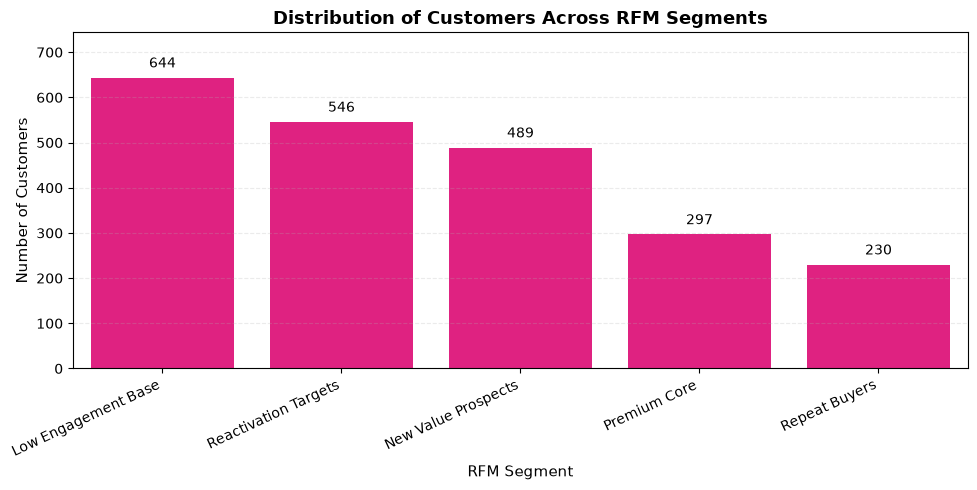

In [178]:
# Visualize the distribution of customers across RFM segments
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=segment_distribution,
    x="RFM_Segment",
    y="Customer_Count",
    color="#FF0281"
)

plt.title("Distribution of Customers Across RFM Segments", fontsize=13, fontweight="bold")
plt.xlabel("RFM Segment", fontsize=11)
plt.ylabel("Number of Customers", fontsize=11)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.25)

## Add customer count labels above the bars
for i, value in enumerate(segment_distribution["Customer_Count"]):
    ax.text(
        i,
        value + 15,
        f"{value}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, segment_distribution["Customer_Count"].max() + 100)

plt.tight_layout()
plt.show()

The bar chart makes the operational weight of each RFM segment immediately visible. The customer base is mainly concentrated in three middle lower priority groups: Low Engagement Base, Reactivation Targets and New Value Prospects. This suggests that a large part of the communication strategy should focus on either recovering inactive value or developing customers who are still recent, but not yet highly profitable.

At the same time, Premium Core and Repeat Buyers are smaller groups, but their size is still large enough to justify dedicated actions. These segments should not be treated as mass audience: they are more suitable for loyalty messages, exclusive offers and value protection campaigns.

### **RFM Segment Summary Profile**
After inspecting the size of each segment, the next step is to profile them using the original RFM variables. This is important because segments labels are useful only if they correspond to clearly different customer behaviours.

For each segment, the analysis summarizes the number of customers, the share of the customer base, the average Recency, Frequency and Monetary value, the total monetary contribution and the percentage of total spending generated by the segment. This allows the segmentation to be evaluated not only in terms of customer value, but also in terms of business value.


In [179]:
# Profile each RFM segment using customer volume and monetary contribution
segment_profile = (
    rfm
    .groupby("RFM_Segment")
    .agg(
        Customer_Count=("ID", "count"),
        Mean_Recency=("Recency", "mean"),
        Mean_Frequency=("Frequency", "mean"),
        Mean_Monetary=("Monetary", "mean"),
        Total_Monetary=("Monetary", "sum")
    )
    .round(2)
)

# Add customer share and monetary share for business interpretation
segment_profile["Customer_Share (%)"] = (
    segment_profile["Customer_Count"] / len(rfm) * 100
).round(2)

segment_profile["Monetary_Share (%)"] = (
    segment_profile["Total_Monetary"] / rfm["Monetary"].sum() * 100
).round(2)

# Reorder columns for readability
segment_profile = segment_profile[
    [
        "Customer_Count",
        "Customer_Share (%)",
        "Mean_Recency",
        "Mean_Frequency",
        "Mean_Monetary",
        "Total_Monetary",
        "Monetary_Share (%)"
    ]
].sort_values("Mean_Monetary", ascending=False)

segment_profile

,Customer_Count,Customer_Share (%),Mean_Recency,Mean_Frequency,Mean_Monetary,Total_Monetary,Monetary_Share (%)
RFM_Segment,,,,,,,
Premium Core,297,13.46,18.74,20.80,1246.38,370176,27.56
Repeat Buyers,230,10.43,42.70,19.42,1017.58,234044,17.42
Reactivation Targets,546,24.75,78.67,17.36,974.15,531884,39.60
Low Engagement Base,644,29.19,62.80,6.66,213.58,137543,10.24
New Value Prospects,489,22.17,19.04,6.93,142.31,69588,5.18


The segment profile confirms that the RFM labels capture meaningful differences in both customer behaviour and business value. Premium Core represents only 13.46% of customers, however generates 26.75% of total monetary value, making it the main segment for loyalty, exclusivity and value protection communication.

Repeat Buyers are smaller, with 10.43% of customers, but still generate 17.42% of monetary value. Their weaker recency compared with Premium Core suggests the need to maintain engagement before activity declines.

The most important recovery opportunity is Reactivation Targets: they represent 24.75% of customers and generate the largest monetary share, 39.60%, but also show very high average recency. This means they have strong historical value, but need targeted reactivation.

Low Engagement Base and New Value Prospects generate lower monetary value relative to their size. They should therefore receive more selective or development oriented communication rather than premium actions.

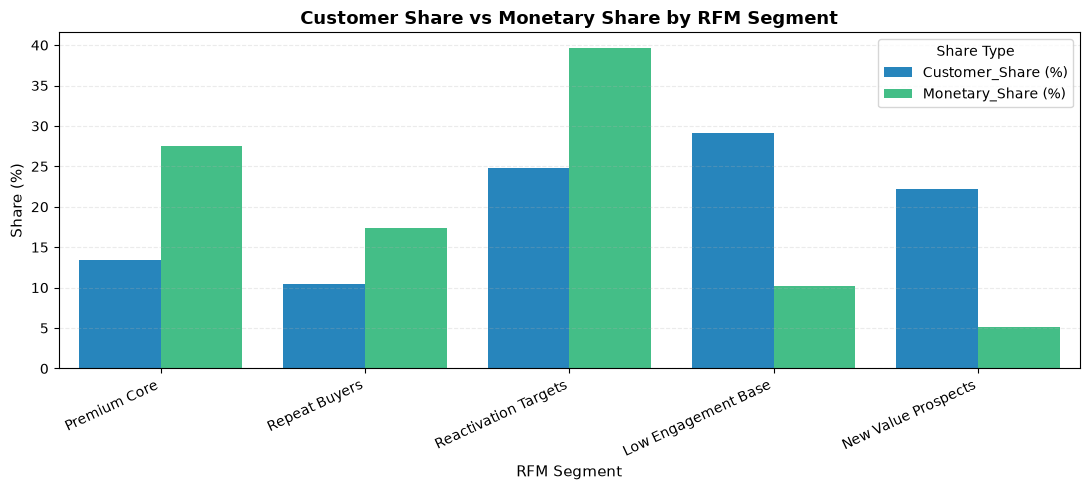

In [180]:
# Compare customer share and monetary share across RFM segments
share_comparison = (
    segment_profile[
        ["Customer_Share (%)", "Monetary_Share (%)"]
    ]
    .reset_index()
    .melt(
        id_vars="RFM_Segment",
        value_vars=["Customer_Share (%)", "Monetary_Share (%)"],
        var_name="Share_Type",
        value_name="Share_Percentage"
    )
)

plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=share_comparison,
    x="RFM_Segment",
    y="Share_Percentage",
    hue="Share_Type",
   palette={
    "Customer_Share (%)": "#0E8CD5",
    "Monetary_Share (%)": "#30D289"
}
)

plt.title("Customer Share vs Monetary Share by RFM Segment", fontsize=13, fontweight="bold")
plt.xlabel("RFM Segment", fontsize=11)
plt.ylabel("Share (%)", fontsize=11)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.legend(title="Share Type")

plt.tight_layout()
plt.show()

The chart makes the imbalance between audience size and monetary distribution easier to compare. The key insight is that segment size alone is not enough to define marketing priority: Reactivation Targets, Premium Core and Repeat Buyers generate a higher monetary share than their customer share, while Low Engagement Base and New Value Prospects show the opposite pattern.

This suggests that communication planning should distinguish between reach-oriented actions and value-oriented actions. Larger low-value segments may require scalable or selective campaigns, while smaller or less recent high-value segments justify more focused communication because they protect or recover a larger share of customer value.

### **Interpretation of RFM Segments**

The RFM segmentation translates individual purchasing behaviour into communication-relevant customer groups. Compared with the previous exploratory analysis, this section does not only describe spending patterns, but organizes customers according to how recently they purchased, how frequently they buy and how much value they generate.

The main insight is that marketing priority should not be based only on customer volume. Some segments, such as Premium Core and Repeat Buyers, are smaller but important for loyalty and value protection. While, Reactivation Targets show a substantial share of monetary value is concentrated in customers whose recent activity has weakened. This makes them a key recovery opportunity rather than a low-priority audience.

At the same time, New Value Prospects and Low Engagement Base require a more selective approach: their communication potential is less about protecting current value and more about developing or testing future engagement through scalable offers and recommendations.

Overall, the RFM analysis provides an interpretable, rule-based segmentation that links behavioural scores to marketing actions. The next section complements this deterministic approach with cluster analysis, which will test whether additional behavioural groups emerge directly from the data without predefined RFM rules.

# **Unsupervised Learning (Cluster Analysis)**

### **Behavioural Cluster Analysis**

After defining the RFM segments, the analysis now moves to K-Means clustering. While RFM assigns customers to predefined groups using three behavioural scores, clustering searches for groups that emerge directly from the data based on customer similarity.

This step uses a broader set of variables than RFM, including channel usage, product spending, web engagement and household composition. The aim is to understand whether customers with similar RFM value may still differ in how they buy, what they buy and how they interact with the company.

From a communication perspective, this matters because two customers can have similar Recency, Frequency and Monetary value, but require different messages or channels. The cluster analysis will be used to enrich the RFM segmentation and to check whether additional behavioural profiles can support more precise marketing actions.



### **Selection of Clustering Variables**

The clustering variables are selected to capture customer behaviour from multiple angles, not only from the value-based perspective already covered by RFM. For this reason, the input features include four groups of information: value and activity, channel behaviour, product spending and customer context. 

Value and activity variables describe the intensity and economic relevance of the relationship. Channel variables help distinguish customers who interact mainly through web, catalogue or store purchases. Product spending variables capture differences in category preferences, while Age and Total_Children provide context for interpreting household-related consumption patterns.

This selection is useful for the project goal because it allows K-Means to detect behavioural profiles that may require different communication actions, even when customers appear similar from an RFM point of view.

In [181]:
# Build a clustering base aligned with the RFM analytical base
cluster_base = df[df["ID"].isin(rfm["ID"])].copy()

# Recreate the engineered RFM variables directly on the clustering base
cluster_base["Frequency"] = (
    cluster_base["NumWebPurchases"] +
    cluster_base["NumCatalogPurchases"] +
    cluster_base["NumStorePurchases"]
)

cluster_base["Monetary"] = cluster_base["Total_Spending"]

# Select variables for behavioral clustering
cluster_features = [
    # Value and activity
    "Income",
    "Recency",
    "Frequency",
    "Monetary",

    # Channel behavior
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",

    # Product spending
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",

    # Customer context
    "Age",
    "Total_Children"
]

# Create the clustering dataset
cluster_data = cluster_base[cluster_features].copy()

# Inspect the selected clustering variables
cluster_data.head()

,Income,Recency,Frequency,Monetary,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Age,Total_Children
0,58138.0,58,22,1617,8,10,4,7,635,88,546,172,88,88,57,0
1,46344.0,38,4,27,1,1,2,5,11,1,6,2,1,6,60,2
2,71613.0,26,20,776,8,2,10,4,426,49,127,111,21,42,49,0
3,26646.0,26,6,53,2,0,4,6,11,4,20,10,3,5,30,1
4,58293.0,94,14,422,5,3,6,5,173,43,118,46,27,15,33,1


The selected clustering dataset is built on the same analytical base used for the RFM segmentation. This ensures that the following comparison between RFM segments and K-Means clusters is performed on a consistent customer population.

Alongside Recency, Frequency and Monetary value, the clustering dataset includes channel behavior, product-category spending and customer context variables. This makes the clustering model richer than RFM alone, because it can identify customers who have similar value scores but differ in how they purchase, which channels they use and which product categories they prefer.

### **Feature Scaling and Preprocessing**

Before applying K-Means, the clustering variables must be scaled because the algorithm is based on distances between customers. In this dataset, variables such as Income, Monetary and product spending amounts have much larger numerical ranges than purchase counts, Recency or Total_Children. Without scaling, the clusters would mainly reflect the largest monetary variables rather than the full behavioural profile.

Standardization is therefore applied so that each variable has mean 0 and standard deviation 1. This allows K-Means to compare customers across value, channels, product preferences and household context with comparable weight.

In [182]:
# Standardize clustering variables so that all features contribute comparably to K-Means distances
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# Convert the scaled array back to a dataframe for easier inspection
cluster_scaled_df = pd.DataFrame(
    cluster_scaled,
    columns=cluster_features,
    index=cluster_data.index
)

# Inspect the standardized clustering variables
cluster_scaled_df.head()

,Income,Recency,Frequency,Monetary,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Age,Total_Children
0,0.291407,0.310912,1.308371,1.673525,1.425194,2.500566,-0.562359,0.714759,0.974963,1.549059,1.687245,2.449823,1.480786,0.849960,1.018496,-1.266906
1,-0.264252,-0.380038,-1.197311,-0.966002,-1.132371,-0.573695,-1.179554,-0.128878,-0.874837,-0.638697,-0.719794,-0.652347,-0.635259,-0.735592,1.274795,1.403705
2,0.926264,-0.794608,1.029962,0.277398,1.425194,-0.232110,1.289228,-0.550697,0.355399,0.568341,-0.180439,1.336691,-0.148812,-0.039496,0.335032,-1.266906
3,-1.192298,-0.794608,-0.918902,-0.922840,-0.767004,-0.915279,-0.562359,0.292940,-0.874837,-0.563257,-0.657389,-0.506363,-0.586614,-0.754928,-1.288195,0.068400
4,0.298709,1.554622,0.194735,-0.310270,0.329095,0.109474,0.054837,-0.128878,-0.394600,0.417461,-0.220556,0.150567,-0.002878,-0.561568,-1.031896,0.068400


The standardized dataset shows values centered around zero, with positive values indicating customers above the average for a given variable and negative values indicating customers below the average. These negative values do not represent negative income, spending or purchases, but they only express each customer's relative position compared with the customer base.

This transformation is important for the cluster analysis because the model now compared customers across different behavioural dimensions with comparable weight. For instance, high product spending, frequent purchases, web activity and household composition can all contribute to the distance calculation, instead of allowing large monetary variables to dominate the clustering result.

### **Choice of K: Elbow Method and Silhouette Score**

**K-Means** requires the number of clusters to be specified before fitting the final model. To avoid choosing this value arbitrarily, different values of k are compared using two complementary criteria.

The **Elbow Method** evaluates how the within-cluster sum of squares decreases as the number of clusters increases. A useful value of k is usually located where the improvement starts to slow down, balancing quality and model simplicity.

The **Silhouette Score** evaluates whether customers are well matched to their own cluster and sufficiently separated from other clusters. In this project, the final choice of k will consider both the statistical indicators and the interpretability of the resulting customer profiles for marketing and communication strategy.

In [183]:
# Test different numbers of clusters
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = kmeans.fit_predict(cluster_scaled_df)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cluster_scaled_df, labels))

# Collect evaluation results in a dataframe
k_evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette_Score": silhouette_scores
})

k_evaluation

,K,Inertia,Silhouette_Score
0,2,21453.937350,0.365699
1,3,18629.192091,0.267823
2,4,17630.536298,0.185041
3,5,16715.518445,0.142092
4,6,15899.292505,0.137586
5,7,15387.495690,0.137728
6,8,14920.820046,0.124525
7,9,14494.860386,0.126083
8,10,14103.232369,0.127294


The evaluation table shows that K=2 obtains the highest Silhouette Score, equal to approximately 0.367. This suggests that the strongest statistical separation in the standardized behavioral data is between two broad customer groups. However, from a marketing perspective, a two-cluster solution may be too coarse because it would probably distinguish mainly between higher-value and lower-value customers, without offering enough detail for differentiated communication actions.

K=3 has a lower but still reasonable Silhouette Score of approximately 0.268 and may provide a more useful balance between statistical separation and marketing interpretability.

From K=4 onward, the Silhouette Score drops sharply and remains low, suggesting that additional clusters may add complexity without creating clearly separated behavioral groups.

For this reason, K=3 is selected as a more balanced solution. It keeps the clustering structure interpretable while allowing the analysis to identify more differentiated behavioral profiles that can be compared with the RFM segments and translated into communication strategy.

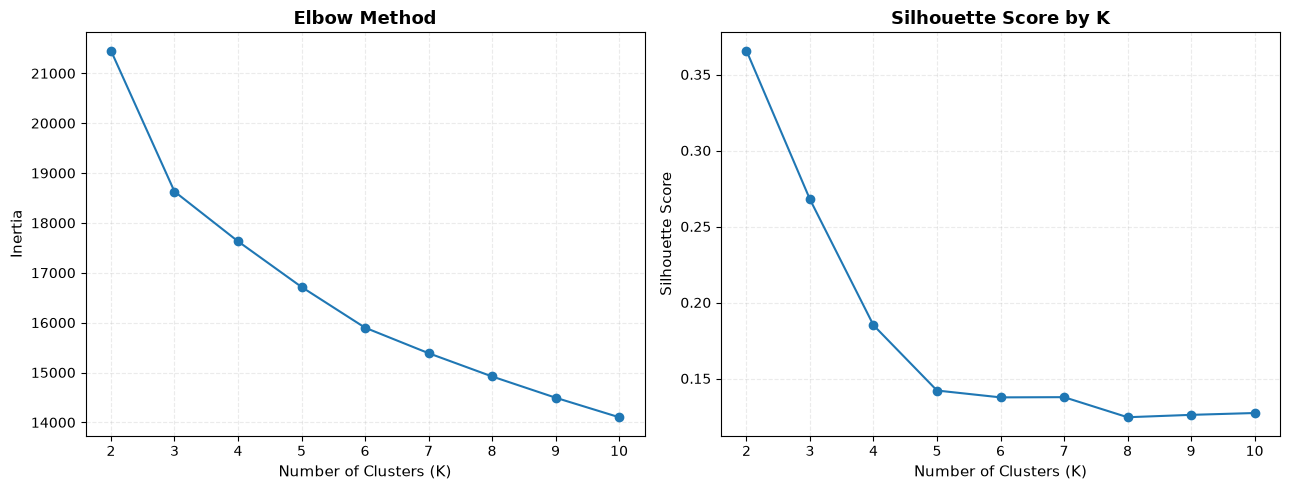

In [184]:
# Visualize the Elbow Method and Silhouette Score for different values of K
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow Method
axes[0].plot(k_evaluation["K"], k_evaluation["Inertia"], marker="o")
axes[0].set_title("Elbow Method", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)", fontsize=11)
axes[0].set_ylabel("Inertia", fontsize=11)
axes[0].grid(axis="both", linestyle="--", alpha=0.25)

# Silhouette Score
axes[1].plot(k_evaluation["K"], k_evaluation["Silhouette_Score"], marker="o")
axes[1].set_title("Silhouette Score by K", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)", fontsize=11)
axes[1].set_ylabel("Silhouette Score", fontsize=11)
axes[1].grid(axis="both", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

The Elbow curve shows the strongest reduction in inertia between K=2 and K=3, after which the improvement becomes more gradual. This suggests that adding a third cluster still provides useful additional structure, while higher values of K mainly add complexity.

The Silhouette Score is highest for K=2, indicating that the clearest statistical separation in the data is between two broad customer groups. However, for this project, a two cluster solution would likely be too limited from a communication perspective, because it may only separate customers into broad high-value and low-value profiles.

For this reason, K=3 is selected as a more balanced solution. It keeps a reasonable Silhouette Score while allowing the analysis to identify more differentiated behavioural profiles that can be compared with the RFM segments and interpreted for marketing actions.

## **Final K-Means Model**

Based on the Elbow Method and Silhouette Score, the final K-Means model is fitted with K=3. Although K=2 shows the strongest statistical separation, K=3 provides a more useful level of detail for behavioural segmentation.

This choice allows the analysis to move beyond a simple broad division between stronger and weaker customers, while still keeping the cluster solution interpretable. The resulting cluster labels are added to the customer-level dataset so that each group can later be profiled, named and compared with the RFM segments.

In [185]:
# Fit the final K-Means model with the selected number of clusters
final_k = 3

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

# Assign each customer to one behavioural cluster
cluster_labels = kmeans_final.fit_predict(cluster_scaled_df)

# Add cluster labels to the clustering dataset and to the RFM table
cluster_data["Cluster"] = cluster_labels
rfm["Cluster"] = cluster_labels

# Inspect the first assigned clusters
cluster_data.head()

,Income,Recency,Frequency,Monetary,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Age,Total_Children,Cluster
0,58138.0,58,22,1617,8,10,4,7,635,88,546,172,88,88,57,0,1
1,46344.0,38,4,27,1,1,2,5,11,1,6,2,1,6,60,2,0
2,71613.0,26,20,776,8,2,10,4,426,49,127,111,21,42,49,0,2
3,26646.0,26,6,53,2,0,4,6,11,4,20,10,3,5,30,1,0
4,58293.0,94,14,422,5,3,6,5,173,43,118,46,27,15,33,1,2


The final K-Means model is fitted on the standardized dataset, so the cluster assignment is based on comparable distances across all selected behavioural variables. The resulting labels are then attached to the original-scale dataset, which makes the next profiling step easier to interpret in business terms.

Furthermore, the numerical cluster labels "0, 1, 2" do not yet have a marketing meaning. They simply indicate data driven groups. Their interpretation will depend on the following profile analysis, where each cluster will be described using the original customer variables.

## **Cluster Size and Distribution**

After assigning each customer to a K-Means cluster, the first step is to inspect the size of each group. This check is important because a clustering solution should not only be statistically reasonable, but also usable for marketing actions.

A very small cluster may represent a niche profile, while a  very large cluster may indicate a broad audience requiring scalable communication. The distribution of customers across clusters therefore helps understand whether the three-cluster solution can support practical segmentation decisions.

In [186]:
# Summarize the number and share of customers in each K-Means cluster
cluster_distribution = (
    cluster_data["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Customer_Count")
)

cluster_distribution["Customer_Share (%)"] = (
    cluster_distribution["Customer_Count"] / len(cluster_data) * 100
).round(2)

cluster_distribution

,Cluster,Customer_Count,Customer_Share (%)
0,0,1059,48.01
1,1,548,24.84
2,2,599,27.15


The three cluster solution produces groups with practical marketing relevance. Cluster 0 is the largest group, with 1059 customers, equal to 48.01% of the customer base. This suggests that almost half of the customer share a broad behavioural pattern, which may require scalable communication actions rather than highly individualized campaign.

Cluster 2 and Cluster 1 are smaller but still substantial, representing 27.15% and 24.59% of customers respectively. Their size is large enough to support segment-level communication, but the labels still have no business meaning at this stage.

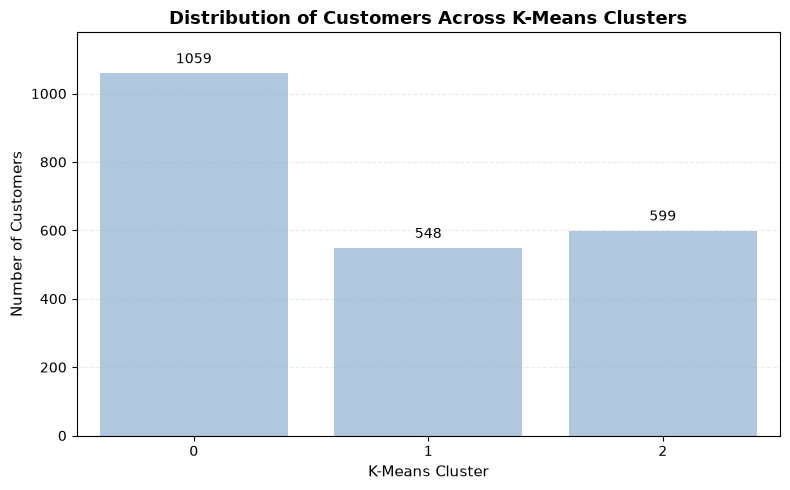

In [187]:
# Visualize the distribution of customers across K-Means clusters
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=cluster_distribution,
    x="Cluster",
    y="Customer_Count",
    color="#A7C7E7"
)

plt.title("Distribution of Customers Across K-Means Clusters", fontsize=13, fontweight="bold")
plt.xlabel("K-Means Cluster", fontsize=11)
plt.ylabel("Number of Customers", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.25)

# Add customer count labels above the bars
for i, value in enumerate(cluster_distribution["Customer_Count"]):
    ax.text(
        i,
        value + 20,
        f"{value}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, cluster_distribution["Customer_Count"].max() + 120)

plt.tight_layout()
plt.show()

The bar chart confirms that the K-Means solution is not made of marginal or unusable groups. The main takeaway is the asymmetry between one broad cluster and two smaller but still actionable segments.

At this stage, however, cluster size only describes the reach of each group. The next step is to examine the original variables to understand what each cluster actually represents in terms of value, channels, product preferences and customer context.

### **Cluster Profiling**

The next step translates the numerical cluster labels into readable customer profiles. Since K-Means was fitted on standardized variables, the profiling is performed on the original scale to interpret each group in terms of income, spending, purchases, web visits and household context.  

This allows the analysis to move from cluster size to cluster meaning, identifying which behaviours make each group relevant for marketing and communication decisions,

In [188]:
# Profile each K-Means cluster using the original variables
cluster_profile = (
    cluster_data
    .groupby("Cluster")
    .agg(
        Customer_Count=("Income", "count"),
        Mean_Income=("Income", "mean"),
        Mean_Recency=("Recency", "mean"),
        Mean_Frequency=("Frequency", "mean"),
        Mean_Monetary=("Monetary", "mean"),
        Mean_Web_Purchases=("NumWebPurchases", "mean"),
        Mean_Catalog_Purchases=("NumCatalogPurchases", "mean"),
        Mean_Store_Purchases=("NumStorePurchases", "mean"),
        Mean_Web_Visits=("NumWebVisitsMonth", "mean"),
        Mean_Wines=("MntWines", "mean"),
        Mean_Fruits=("MntFruits", "mean"),
        Mean_Meat=("MntMeatProducts", "mean"),
        Mean_Fish=("MntFishProducts", "mean"),
        Mean_Sweets=("MntSweetProducts", "mean"),
        Mean_Gold=("MntGoldProds", "mean"),
        Mean_Age=("Age", "mean"),
        Mean_Total_Children=("Total_Children", "mean")
    )
    .round(2)
)

# Add customer share for easier business interpretation
cluster_profile["Customer_Share (%)"] = (
    cluster_profile["Customer_Count"] / len(cluster_data) * 100
).round(2)

# Reorder columns for readability
cluster_profile = cluster_profile[
    [
        "Customer_Count",
        "Customer_Share (%)",
        "Mean_Income",
        "Mean_Recency",
        "Mean_Frequency",
        "Mean_Monetary",
        "Mean_Web_Purchases",
        "Mean_Catalog_Purchases",
        "Mean_Store_Purchases",
        "Mean_Web_Visits",
        "Mean_Wines",
        "Mean_Fruits",
        "Mean_Meat",
        "Mean_Fish",
        "Mean_Sweets",
        "Mean_Gold",
        "Mean_Age",
        "Mean_Total_Children"
    ]
]

cluster_profile

,Customer_Count,Customer_Share (%),Mean_Income,Mean_Recency,Mean_Frequency,Mean_Monetary,Mean_Web_Purchases,Mean_Catalog_Purchases,Mean_Store_Purchases,Mean_Web_Visits,Mean_Wines,Mean_Fruits,Mean_Meat,Mean_Fish,Mean_Sweets,Mean_Gold,Mean_Age,Mean_Total_Children
Cluster,,,,,,,,,,,,,,,,,,
0,1059,48.01,35250.62,49.10,6.08,103.84,2.20,0.58,3.29,6.42,46.85,4.98,24.18,7.11,5.03,15.69,42.82,1.26
1,548,24.84,76324.00,50.47,19.80,1416.30,5.19,6.18,8.43,2.84,617.53,71.10,472.22,103.49,73.69,78.27,45.49,0.24
2,599,27.15,59185.25,47.49,17.55,763.16,6.45,3.18,7.92,5.58,479.56,23.38,142.03,31.78,23.57,62.85,48.70,1.06


The cluster profile shows three distinct behavioral groups.

"Cluster 0" is the largest group, but it has the weakest economic profile: it shows the lowest average income, frequency and monetary value. At the same time, it has the highest average number of web visits per month. This suggests a low-conversion browsing profile: these customers show digital interest, but this interest is not translated into actual purchases.

"Cluster 1" is the strongest value group, with the highest average income, frequency and monetary value. It is also active across purchase channels, especially store and catalogue purchases, and shows the highest spending across several product categories. This supports its interpretation as a premium omnichannel customer group.

"Cluster 2" is an intermediate-value group. Its monetary value is lower than Cluster 1 but clearly higher than Cluster 0, and it shows relatively strong web purchasing activity and web engagement. This makes it a commercially relevant digital segment, less premium than Cluster 1 but more active and valuable than the low-conversion group.

### **Cluster Visualization**

To make the cluster profiles easier to compare, the next step visualizes the average standardized profile of each cluster. While the previous table used original values for business interpretation, the heatmap uses standardized values to show which variables are above or below the overall customer average.

This visualization is useful because it highlights the behavioural signature of each cluster: value intensity, channel preference, product spending, web engagement and household context.

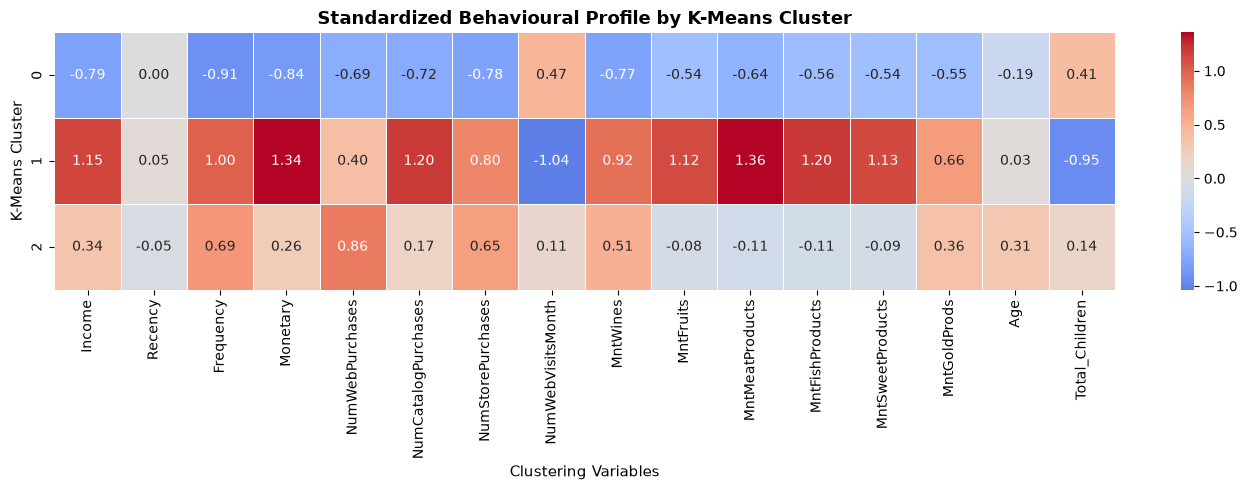

In [189]:
# Calculate the average standardized profile of each cluster
cluster_scaled_with_labels = cluster_scaled_df.copy()
cluster_scaled_with_labels["Cluster"] = cluster_labels

cluster_heatmap = (
    cluster_scaled_with_labels
    .groupby("Cluster")
    .mean()
)

plt.figure(figsize=(14, 5))

sns.heatmap(
    cluster_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Standardized Behavioural Profile by K-Means Cluster", fontsize=13, fontweight="bold")
plt.xlabel("Clustering Variables", fontsize=11)
plt.ylabel("K-Means Cluster", fontsize=11)

plt.tight_layout()
plt.show()

The heatmap summarizes the standardized profile of each K-Means cluster compared with the overall customer average. Positive values indicate that a cluster is above the customer-base average for a given variable, while negative values indicate that it is below average.

Cluster 0 shows below-average income, frequency, monetary value and product spending, but above-average web visits. This confirms its interpretation as a low-conversion browsing group: these customers interact digitally, but their browsing activity does not translate into strong purchasing behavior.

Cluster 1 shows the strongest positive values for income, frequency, monetary value, catalogue purchases, store purchases and product spending. This supports its interpretation as a premium omnichannel group, because these customers combine high value with broad purchasing activity across channels and product categories.

Cluster 2 has an intermediate profile, with above-average web purchases and web visits, but lower product spending than Cluster 1. This suggests a digitally active segment that is commercially relevant, but less premium than the omnichannel high-value group.

### **Cluster Naming and Marketing Personas**

Based on the cluster profile and heatmap, each numerical cluster is now assigned a descriptive marketing persona. The names are derived from the main behavioural signals observed in the data: value intensity, channel usage, product-category preferences and digital engagement.

In [190]:
# Assign descriptive marketing persona names to the K-Means clusters
cluster_persona_map = {
    0: "Low-Conversion Web Browsers",
    1: "Premium Omnichannel Buyers",
    2: "Digitally Active Selectors"
}

cluster_data["Cluster_Persona"] = cluster_data["Cluster"].map(cluster_persona_map)
rfm["Cluster_Persona"] = rfm["Cluster"].map(cluster_persona_map)

# Verify the assigned cluster persona labels
cluster_data[["Cluster", "Cluster_Persona"]].head()

,Cluster,Cluster_Persona
0,1,Premium Omnichannel Buyers
1,0,Low-Conversion Web Browsers
2,2,Digitally Active Selectors
3,0,Low-Conversion Web Browsers
4,2,Digitally Active Selectors


The assigned persona names summarize the main behavioural identity of each cluster.   
**"Premium Omnichannel Buyers"** captures the high-value group with strong spending and activity across multiple channels.
**"Digitally Active Selectors"** describes customers who are commercially active and relatively strong in web purchases, but less premium and more selective in product spending.

**"Low-Conversion Web Browsers"** is especially relevant for communication strategy because it reframes the largest low-value cluster as a digital conversion issue rather than simple a weak customer group. These customers show browsing activity but limited purchasing, suggesting that future campaigns may need to reduce friction, improve offer relevance or encourage conversion from website interest to actual buying.

### **Interpretation of Behavioural Persona Distribution**

The customer base is distributed across three distinct behavioural personas. The largest group is **Low-Conversion Web Browsers** (48%), followed by **Digitally Active Selectors** (27%) and **Premium Omnichannel Buyers** (25%).

This means that the business opportunity is not concentrated only in the highest-value customers. A large share of the customer base shows weaker conversion and may require activation or conversion-oriented communication, while the premium segment remains smaller but strategically important for loyalty and value protection.

In [191]:
# Summarize customer share by K-Means persona for presentation use
persona_distribution = (
    cluster_data["Cluster_Persona"]
    .value_counts()
    .rename_axis("Persona")
    .reset_index(name="Customer_Count")
)

persona_distribution["Customer_Share (%)"] = (
    persona_distribution["Customer_Count"] / len(cluster_data) * 100
).round(1)

# Order personas for presentation
persona_order = [
    "Low-Conversion Web Browsers",
    "Digitally Active Selectors",
    "Premium Omnichannel Buyers"
]

persona_distribution["Persona"] = pd.Categorical(
    persona_distribution["Persona"],
    categories=persona_order,
    ordered=True
)

persona_distribution = persona_distribution.sort_values("Persona")

persona_distribution

,Persona,Customer_Count,Customer_Share (%)
0,Low-Conversion Web Browsers,1059,48.0
1,Digitally Active Selectors,599,27.2
2,Premium Omnichannel Buyers,548,24.8


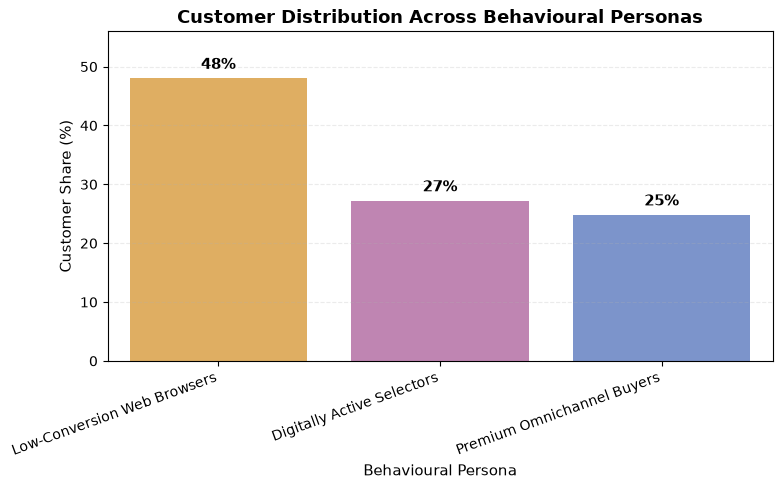

In [192]:
# Visualize the distribution of behavioural personas
plt.figure(figsize=(8, 5))

persona_colors = {
    "Low-Conversion Web Browsers": "#F4B24D",   # orange
    "Digitally Active Selectors": "#C97BB8",    # pink/purple
    "Premium Omnichannel Buyers": "#6F8FD8"     # blue
}

ax = sns.barplot(
    data=persona_distribution,
    x="Persona",
    y="Customer_Share (%)",
    hue="Persona",
    palette=persona_colors,
    dodge=False,
    legend=False
)

plt.title("Customer Distribution Across Behavioural Personas", fontsize=13, fontweight="bold")
plt.xlabel("Behavioural Persona", fontsize=11)
plt.ylabel("Customer Share (%)", fontsize=11)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.25)

# Add percentage labels above the bars
for i, value in enumerate(persona_distribution["Customer_Share (%)"]):
    ax.text(
        i,
        value + 1,
        f"{value:.0f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, persona_distribution["Customer_Share (%)"].max() + 8)
plt.tight_layout()
plt.show()

### **Comparison Between K-Means Clusters and RFM Segments**

After naming the K-Means clusters, the next step is to compare them with the RFM segments. This comparison is important because the two methods are based on different logics: RFM assigns customers through predefined value-based rules, while K-Means groups customers according to similarity across a broader behavioural profile.

The objective is to understand whether the clusters overlap with the RFM segments and whether the cluster analysis captures additional information that RFM may miss, such as channel behaviour, product preferences, web engagement or household context.

In [193]:
# Compare K-Means personas with RFM segments using customer counts
rfm_cluster_comparison = pd.crosstab(
    rfm["Cluster_Persona"],
    rfm["RFM_Segment"]
)

rfm_cluster_comparison

RFM_Segment,Low Engagement Base,New Value Prospects,Premium Core,Reactivation Targets,Repeat Buyers
Cluster_Persona,,,,,
Digitally Active Selectors,54,62,119,231,133
Low-Conversion Web Browsers,549,427,0,83,0
Premium Omnichannel Buyers,41,0,178,232,97


In [194]:
# Normalize by cluster persona to understand the RFM composition of each K-Means cluster
rfm_cluster_comparison_pct = (
    pd.crosstab(
        rfm["Cluster_Persona"],
        rfm["RFM_Segment"],
        normalize="index"
    ) * 100
).round(2)

rfm_cluster_comparison_pct

RFM_Segment,Low Engagement Base,New Value Prospects,Premium Core,Reactivation Targets,Repeat Buyers
Cluster_Persona,,,,,
Digitally Active Selectors,9.02,10.35,19.87,38.56,22.2
Low-Conversion Web Browsers,51.84,40.32,0.00,7.84,0.0
Premium Omnichannel Buyers,7.48,0.00,32.48,42.34,17.7


The comparison shows that K-Means personas and RFM segments partially overlap, but they are not equivalent. This confirms that the two methods capture different dimensions of customer behavior.

"Premium Omnichannel Buyers" are strongly concentrated in higher-value RFM groups: 42.34% belong to "Reactivation Targets", 32.48% to "Premium Core" and 17.70% to "Repeat Buyers". This suggests that the cluster captures customers with strong economic value, but adds a behavioral dimension related to multichannel purchasing and broad product spending.

"Low-Conversion Web Browsers" mainly overlap with lower or underdeveloped RFM segments: 51.84% belong to "Low Engagement Base" and 40.32% to "New Value Prospects". This confirms their weaker current value, but the K-Means profile adds a more actionable interpretation: these customers are not only low-value customers, but also digitally active browsers who may require conversion-oriented communication.

"Digitally Active Selectors" are the most mixed persona across RFM segments. They include customers from "Reactivation Targets", "Repeat Buyers", "Premium Core", "New Value Prospects" and "Low Engagement Base". This suggests that web-oriented behavior cuts across different RFM statuses, which is important for communication strategy because customers with different value levels may still require similar digital or channel-related messages.

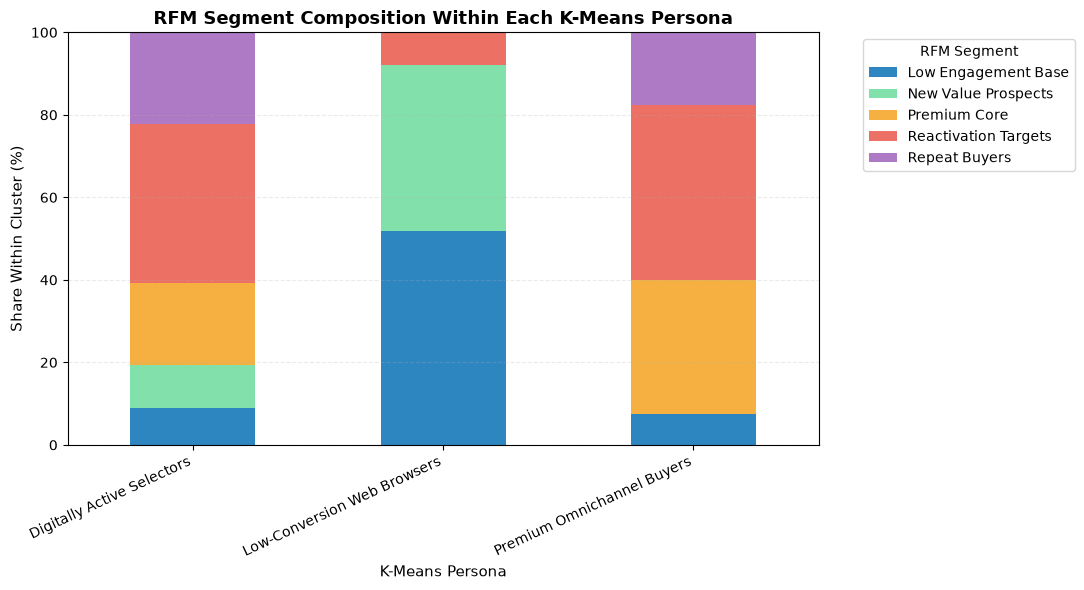

In [195]:
# Visualize the overlap between K-Means personas and RFM segments
rfm_cluster_comparison_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=["#2E86C1", "#82E0AA", "#F5B041", "#EC7063", "#AF7AC5"]
)

plt.title(
    "RFM Segment Composition Within Each K-Means Persona",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("K-Means Persona", fontsize=11)
plt.ylabel("Share Within Cluster (%)", fontsize=11)
plt.xticks(rotation=25, ha="right")
plt.legend(title="RFM Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

The stacked bar chart visually confirms that the relationship between RFM segments and K-Means personas is partial rather than one-to-one.

"Low-Conversion Web Browsers" are the most concentrated persona, with most customers belonging to "Low Engagement Base" and "New Value Prospects". This supports the interpretation of this group as a lower-value audience with digital interest that has not yet converted into strong purchasing behavior.

"Premium Omnichannel Buyers" are concentrated in the strongest or most recoverable RFM groups, especially "Reactivation Targets", "Premium Core" and "Repeat Buyers". This confirms that the persona captures high-value customers, while adding information about multichannel behavior and product-category intensity.

"Digitally Active Selectors" are more distributed across RFM segments. This shows that digital activity is not limited to one value category and can cut across different customer priorities. For this reason, the K-Means layer is useful because it helps refine communication channels and message framing beyond the RFM score alone.

### **Interpretation: What Clustering Adds Beyond RFM**

The comparison between RFM segments and K-Means personas shows a partial overlap rather than a one-to-one match. RFM remains useful as a clear value-based framework because it prioritizes customers according to recency, purchase frequency and monetary value. K-Means, however, adds a broader behavioral layer by considering channel usage, web engagement, household context and product-category preferences.

The main added insight is that customers with similar RFM value can still require different communication approaches. For example, "Low-Conversion Web Browsers" are not only low-value or underdeveloped customers: they also show digital browsing activity without strong purchase conversion. This suggests a communication issue related to offer relevance, purchase friction or conversion incentives.

At the other end, "Premium Omnichannel Buyers" show that high-value customers are valuable not only because they spend more, but also because they interact across multiple channels and product categories. This makes them suitable for loyalty, value protection and premium relationship-oriented communication.

"Digitally Active Selectors" show that digital behavior can cut across different RFM segments. For this reason, communication channels should not be chosen only from RFM scores: customers with different value levels may still require similar digital personalization or web-based recommendations.

Overall, RFM helps define customer priority, while K-Means helps refine the message, channel and campaign logic. Together, the two methods provide a stronger foundation for the final communication strategy.

## **Communication Strategy**

The final step translates the analytical findings into communication decisions. The strategy combines three layers developed in the previous sections: RFM segments, K-Means behavioural personas and the hidden opportunity represented by customers spending below their income potential.

Rather than assigning a generic channel to each segment, the strategy uses a trigger-based communication logic. This means that each action is connected to a specific customer condition, such as high value, weak recency, repeated web visits without conversion or spending below expected potential. 

This approach makes the strategy more actionable: RFM defines customer priority, K-Means refines channel and behavioural context and the income-potential insight adds a cross-cutting audience that neither segmentation method alone would have identified.

### **Strategy Framework**

The strategy is organized around a simple campaign logic: each target group is linked to a communication objective, a recommended channel, a trigger condition and a message tone. This makes the final recommendation more operational, because the analysis is not translated only into segment names, but into possible campaign actions.  
ca
The framework combines value priority and behavioural context: high-value customers require loyalty actions, lapsed valuable customers require reactivation, digitally engaged low converters require friction-reduction messages and customers spending below their income potential require value development communication.

In [196]:
# Build a customer-level strategy base by combining original variables with RFM and cluster labels
strategy_base = df.merge(
    rfm[["ID", "RFM_Segment", "Cluster_Persona"]],
    on="ID",
    how="left"
)

# Create the Below Income Potential flag using the residual threshold defined in the EDA
strategy_base["Below_Income_Potential"] = (
    strategy_base["Spending_Residual"] < residual_threshold
)

# Build profiles for K-Means personas using real observed values
persona_strategy = (
    strategy_base
    .groupby("Cluster_Persona")
    .agg(
        Customer_Count=("ID", "count"),
        Mean_Monetary=("Total_Spending", "mean"),
        Mean_Web_Visits=("NumWebVisitsMonth", "mean")
    )
    .reset_index()
    .rename(columns={"Cluster_Persona": "Target_Group"})
)

# Add communication logic for K-Means personas
persona_strategy["Communication_Objective"] = persona_strategy["Target_Group"].map({
    "Premium Omnichannel Buyers": "Loyalty and value protection",
    "Digitally Active Selectors": "Development and curated recommendations",
    "Low-Conversion Web Browsers": "Digital conversion improvement"
})

persona_strategy["Recommended_Channel"] = persona_strategy["Target_Group"].map({
    "Premium Omnichannel Buyers": "Email + Catalogue",
    "Digitally Active Selectors": "Web personalization + Email",
    "Low-Conversion Web Browsers": "Retargeting + Email"
})

# Add RFM Reactivation Targets as a cross-cutting strategic audience
reactivation_group = strategy_base[strategy_base["RFM_Segment"] == "Reactivation Targets"]

reactivation_strategy = pd.DataFrame([{
    "Target_Group": "Reactivation Targets",
    "Customer_Count": reactivation_group["ID"].count(),
    "Mean_Monetary": reactivation_group["Total_Spending"].mean(),
    "Mean_Web_Visits": reactivation_group["NumWebVisitsMonth"].mean(),
    "Communication_Objective": "Win-back and value recovery",
    "Recommended_Channel": "Personalized Email"
}])

# Add Below Income Potential Customers as a cross-cutting hidden opportunity
below_potential_group = strategy_base[strategy_base["Below_Income_Potential"]]

below_potential_strategy = pd.DataFrame([{
    "Target_Group": "Below Income Potential Customers",
    "Customer_Count": below_potential_group["ID"].count(),
    "Mean_Monetary": below_potential_group["Total_Spending"].mean(),
    "Mean_Web_Visits": below_potential_group["NumWebVisitsMonth"].mean(),
    "Communication_Objective": "Latent value activation",
    "Recommended_Channel": "Premium discovery email"
}])

# Combine all strategic target groups
strategy_map = pd.concat(
    [persona_strategy, reactivation_strategy, below_potential_strategy],
    ignore_index=True
)

strategy_map[
    [
        "Target_Group",
        "Customer_Count",
        "Mean_Monetary",
        "Mean_Web_Visits",
        "Communication_Objective",
        "Recommended_Channel"
    ]
].round(2)

,Target_Group,Customer_Count,Mean_Monetary,Mean_Web_Visits,Communication_Objective,Recommended_Channel
0,Digitally Active Selectors,599,763.16,5.58,Development and curated recommendations,Web personalization + Email
1,Low-Conversion Web Browsers,1059,103.84,6.42,Digital conversion improvement,Retargeting + Email
2,Premium Omnichannel Buyers,548,1416.30,2.84,Loyalty and value protection,Email + Catalogue
3,Reactivation Targets,546,974.15,4.55,Win-back and value recovery,Personalized Email
4,Below Income Potential Customers,260,281.60,4.41,Latent value activation,Premium discovery email


The strategy map translates the analytical profiles into communication priorities.

"Premium Omnichannel Buyers" represent the highest-value persona, with the strongest average monetary value and purchase frequency. Their dominant RFM association with "Reactivation Targets" suggests that they are valuable customers who should not be treated only as loyal customers, but also as customers whose relationship may need to be protected or reactivated before value is lost.

"Digitally Active Selectors" show an intermediate but commercially relevant profile. They spend less than the premium omnichannel group, but they still display meaningful purchasing activity and digital engagement. This makes them suitable for personalized recommendations, product discovery campaigns and web-oriented communication.

"Low-Conversion Web Browsers" have the lowest monetary value and frequency, but the highest average number of web visits. This indicates that their main issue is not absence of interest, but weak conversion from browsing to purchasing. For this reason, they should be targeted with conversion-oriented messages, clearer incentives and friction-reduction communication.

Overall, the strategy map shows that the final communication strategy should not be based only on customer value. It should also consider how customers interact with the brand, which channels they use and whether their behavior suggests loyalty, reactivation potential or conversion friction.

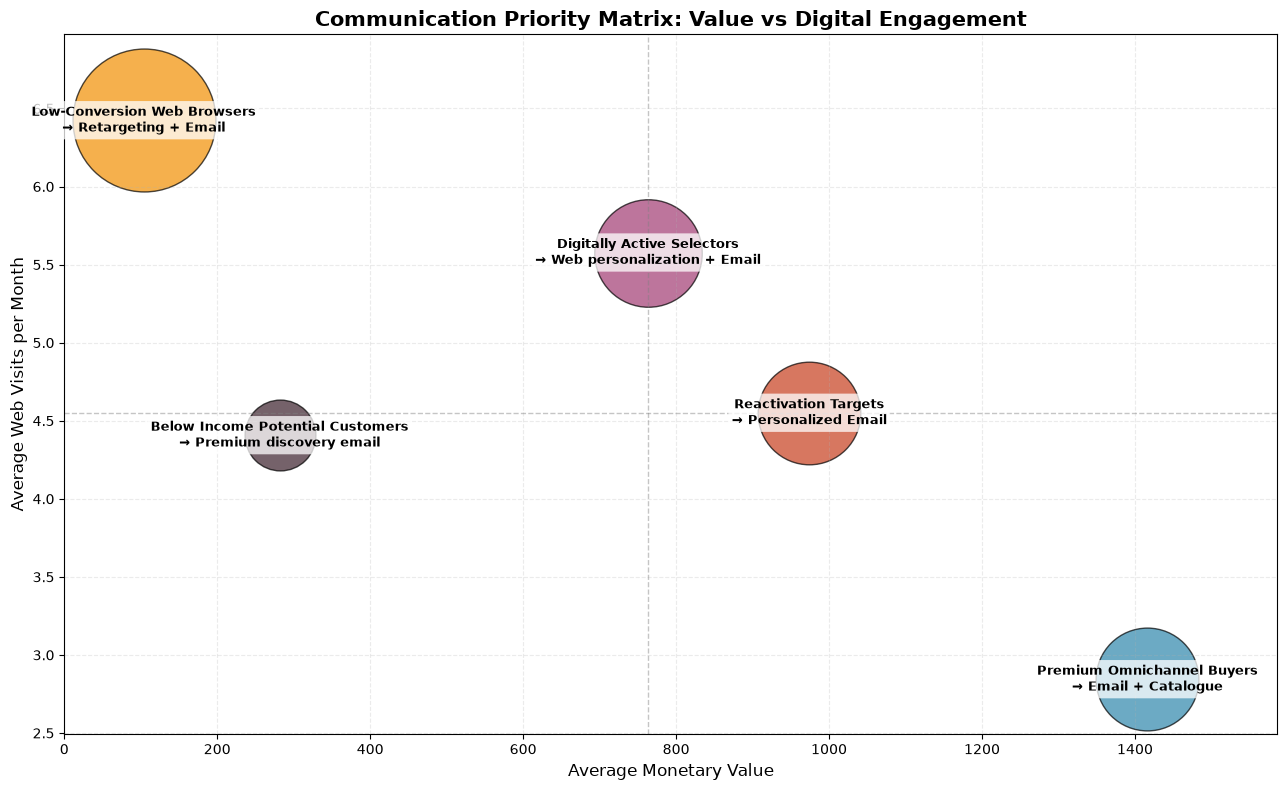

In [197]:
# Visualize the communication priority matrix using real target-group metrics
plt.figure(figsize=(13, 8))

# Define custom colors for each strategic target group
colors = {
    "Premium Omnichannel Buyers": "#2E86AB",  # Blue: high-value, loyal
    "Digitally Active Selectors": "#A23B72",  # Purple: engaged, but not high-value
    "Low-Conversion Web Browsers": "#F18F01",  # Orange: low engagement, low value
    "Reactivation Targets": "#C73E1D",  # Red: potential churners
    "Below Income Potential Customers": "#3B1F2B"  # Dark Gray: low income, low engagement
}

# Scale bubble size for readability
bubble_size = strategy_map["Customer_Count"] * 10

for _, row in strategy_map.iterrows():
    plt.scatter(
        row["Mean_Monetary"],
        row["Mean_Web_Visits"],
        s=bubble_size.loc[row.name],
        color=colors[row["Target_Group"]],
        alpha=0.70,
        edgecolor="black",
        linewidth=1
    )

    plt.annotate(
        f"{row['Target_Group']}\n→ {row['Recommended_Channel']}",
        xy=(row["Mean_Monetary"], row["Mean_Web_Visits"]),
        ha="center",
        va="center",
        fontsize=9.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.75
        )
    )

plt.title(
    "Communication Priority Matrix: Value vs Digital Engagement",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Average Monetary Value", fontsize=12)
plt.ylabel("Average Web Visits per Month", fontsize=12)

plt.xlim(0, strategy_map["Mean_Monetary"].max() * 1.12)
plt.ylim(
    strategy_map["Mean_Web_Visits"].min() - 0.35,
    strategy_map["Mean_Web_Visits"].max() + 0.55
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add data-driven reference lines to make the matrix easier to interpret
value_threshold = strategy_map["Mean_Monetary"].median()
engagement_threshold = strategy_map["Mean_Web_Visits"].median()

plt.axvline(
    value_threshold,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.45
)

plt.axhline(
    engagement_threshold,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.45
)

plt.grid(axis="both", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

The Communication Priority Matrix translates the analytical segments into strategic communication priorities by comparing customer value and engagement potential.

"Premium Omnichannel Buyers" occupy the high-value area of the matrix. They represent the strongest economic segment and should be managed through loyalty protection, premium relationship building and value-preserving communication.

"Digitally Active Selectors" show a relevant combination of medium-high value and digital engagement. They are suitable for personalized recommendations, product discovery messages and web-based campaigns designed to increase basket size and deepen product-category exploration.

"Low-Conversion Web Browsers" have low current value but high digital interaction. Their position suggests that the main opportunity is not awareness, but conversion. For this reason, communication should focus on reducing purchase friction, clarifying the offer and creating stronger incentives to transform visits into purchases.

"Reactivation Targets" remain strategically important because they represent customers with past value who may need to be recovered before their relationship with the brand weakens further.

"Below Income Potential Customers" represent a latent opportunity: they have higher economic capacity than their observed spending suggests. Their communication should focus on value development rather than generic discounting, using more relevant offers, premium discovery and tailored recommendations.

Overall, the matrix shows that communication priorities should combine current value, behavioral engagement and unrealized potential. This makes the final strategy more actionable than a simple ranking by spending alone.

### **Trigger Based Communication Strategy Table**

The following cards translate the main analytical outputs into practical campaign rules, linking each strategic audience to the most appropriate communication objective, channel, trigger and tone.

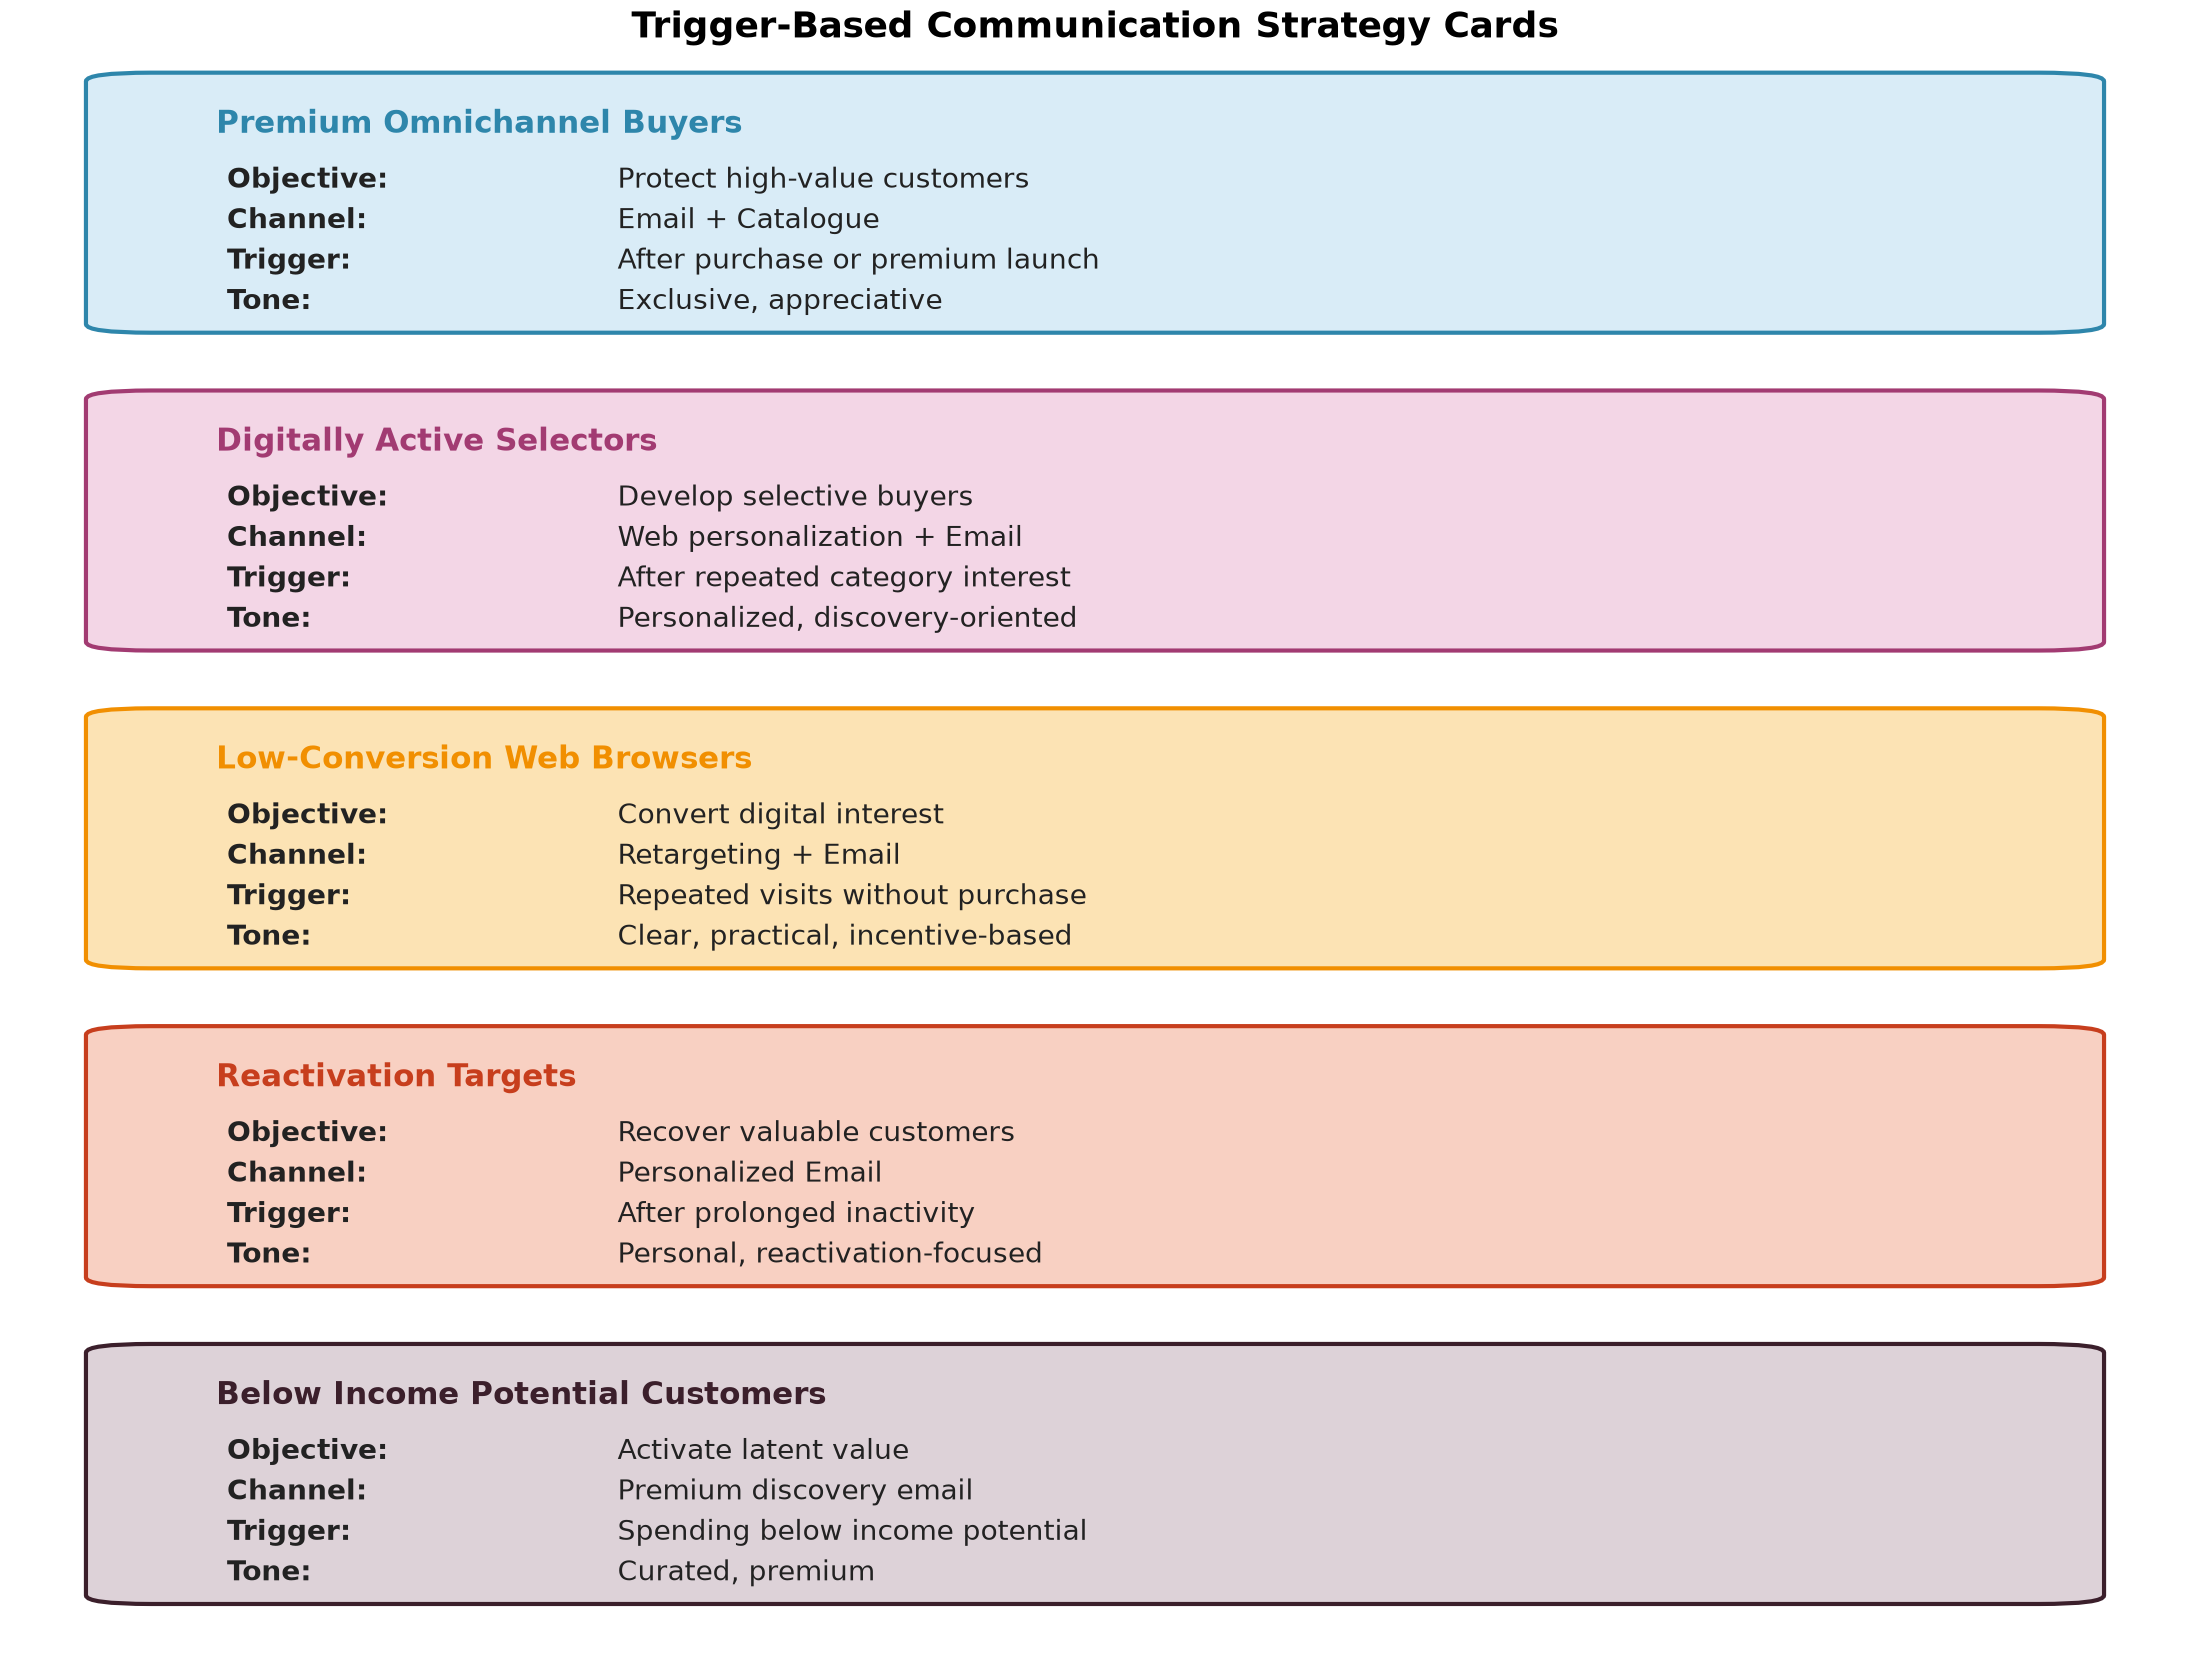

In [198]:
# Short version for visual cards
strategy_cards = pd.DataFrame([
    {
        "Target_Group": "Premium Omnichannel Buyers",
        "Objective": "Protect high-value customers",
        "Channel": "Email + Catalogue",
        "Trigger": "After purchase or premium launch",
        "Tone": "Exclusive, appreciative"
    },
    {
        "Target_Group": "Digitally Active Selectors",
        "Objective": "Develop selective buyers",
        "Channel": "Web personalization + Email",
        "Trigger": "After repeated category interest",
        "Tone": "Personalized, discovery-oriented"
    },
    {
        "Target_Group": "Low-Conversion Web Browsers",
        "Objective": "Convert digital interest",
        "Channel": "Retargeting + Email",
        "Trigger": "Repeated visits without purchase",
        "Tone": "Clear, practical, incentive-based"
    },
    {
        "Target_Group": "Reactivation Targets",
        "Objective": "Recover valuable customers",
        "Channel": "Personalized Email",
        "Trigger": "After prolonged inactivity",
        "Tone": "Personal, reactivation-focused"
    },
    {
        "Target_Group": "Below Income Potential Customers",
        "Objective": "Activate latent value",
        "Channel": "Premium discovery email",
        "Trigger": "Spending below income potential",
        "Tone": "Curated, premium"
    }
])

card_colors = {
    "Premium Omnichannel Buyers": "#D9ECF7",
    "Digitally Active Selectors": "#F3D6E6",
    "Low-Conversion Web Browsers": "#FCE3B4",
    "Reactivation Targets": "#F8D0C2",
    "Below Income Potential Customers": "#DDD2D8"
}

border_colors = {
    "Premium Omnichannel Buyers": "#2E86AB",
    "Digitally Active Selectors": "#A23B72",
    "Low-Conversion Web Browsers": "#F18F01",
    "Reactivation Targets": "#C73E1D",
    "Below Income Potential Customers": "#3B1F2B"
}

fig, ax = plt.subplots(figsize=(22, 18))
ax.set_xlim(0, 1)
ax.set_ylim(0, 5.7)
ax.axis("off")

card_x = 0.06
card_width = 0.88
card_height = 0.85
y_positions = [4.65, 3.55, 2.45, 1.35, 0.25]

for i, row in strategy_cards.iterrows():
    y = y_positions[i]
    target = row["Target_Group"]

    card = patches.FancyBboxPatch(
        (card_x, y),
        card_width,
        card_height,
        boxstyle="round,pad=0.025,rounding_size=0.03",
        linewidth=3,
        edgecolor=border_colors[target],
        facecolor=card_colors[target]
    )
    ax.add_patch(card)

    # Title
    ax.text(
        card_x + 0.035,
        y + card_height - 0.10,
        target,
        fontsize=22,
        fontweight="bold",
        color=border_colors[target],
        va="top"
    )

    # Content
    fields = [
        ("Objective", row["Objective"]),
        ("Channel", row["Channel"]),
        ("Trigger", row["Trigger"]),
        ("Tone", row["Tone"])
    ]

    y_text = y + card_height - 0.30

    for label, value in fields:
        ax.text(
            card_x + 0.04,
            y_text,
            f"{label}:",
            fontsize=20,
            fontweight="bold",
            color="#222222",
            va="top"
        )

        ax.text(
            card_x + 0.22,
            y_text,
            value,
            fontsize=20,
            color="#222222",
            va="top"
        )

        y_text -= 0.14

plt.suptitle(
    "Trigger-Based Communication Strategy Cards",
    fontsize=26,
    fontweight="bold",
    y=0.93
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The strategy cards translate the analytical findings into operational communication actions. Each target group is connected to a specific marketing objective, preferred channel logic, campaign trigger and message tone.

The cards show that the final strategy is not based only on segment size or current spending. "Premium Omnichannel Buyers" require loyalty protection and premium relationship-building actions, while "Digitally Active Selectors" are better addressed through personalized digital recommendations and product discovery messages.

"Low-Conversion Web Browsers" represent a different type of opportunity: they are digitally active, but their engagement does not yet translate into strong purchasing behavior. For this reason, their communication should focus on conversion, offer clarity and reduction of purchase friction.

The additional strategic groups complete the framework. "Reactivation Targets" require recovery-oriented communication before previous value is lost, while "Below Income Potential Customers" should be approached with value-development messages that activate their latent spending potential.

Together, the RFM framework, the K-Means behavioral personas and the income-potential insight provide a multi-layered foundation for a data-driven communication strategy that goes beyond simple demographic targeting.

In this sense, the final strategy turns customer analytics into an actionable communication plan, where every marketing action is guided by observed value, behavioral signals and unrealized customer potential.